## Part 1. 의료비 예측 모델 구축 및 영향 요인 분석

In [45]:
pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 3.0 MB/s  0:00:023.0 MB/s eta 0:00:01:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

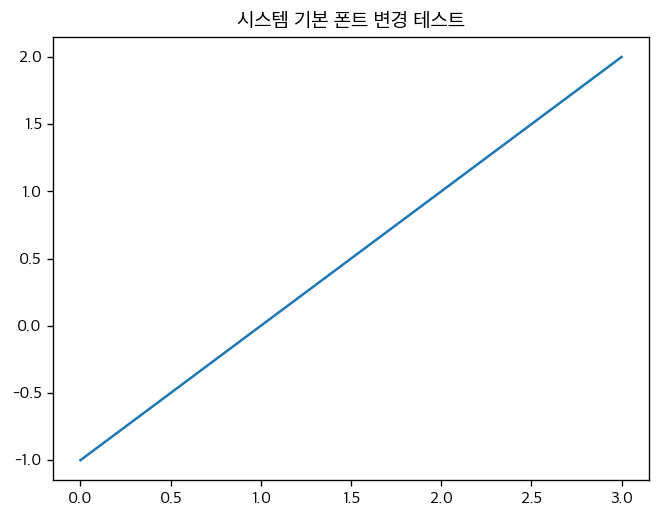

In [8]:
import matplotlib.pyplot as plt

# AppleGothic 대신 시스템 기본 한글 서체 이름 지정
plt.rc('font', family='Apple SD Gothic Neo')
plt.rc('axes', unicode_minus=False)

plt.plot([-1, 0, 1, 2],)
plt.title('시스템 기본 폰트 변경 테스트')
plt.show()



In [5]:
# 실행 전 터미널에서: pip install "shap==0.46.0" "numpy<2.0"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 전처리
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# 성능 지표
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, mean_absolute_percentage_error)

# 변수 중요도
from sklearn.inspection import permutation_importance

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("라이브러리 임포트 완료")

라이브러리 임포트 완료


In [6]:
df = pd.read_csv('insurance.csv')

print(f"데이터 크기: {df.shape}")
print(f"\n컬럼 및 타입:")
print(df.dtypes)
print(f"\n결측값:")
print(df.isnull().sum())
print(f"\n기초 통계:")
print(df.describe())
df.head()

데이터 크기: (1338, 7)

컬럼 및 타입:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

결측값:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

기초 통계:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


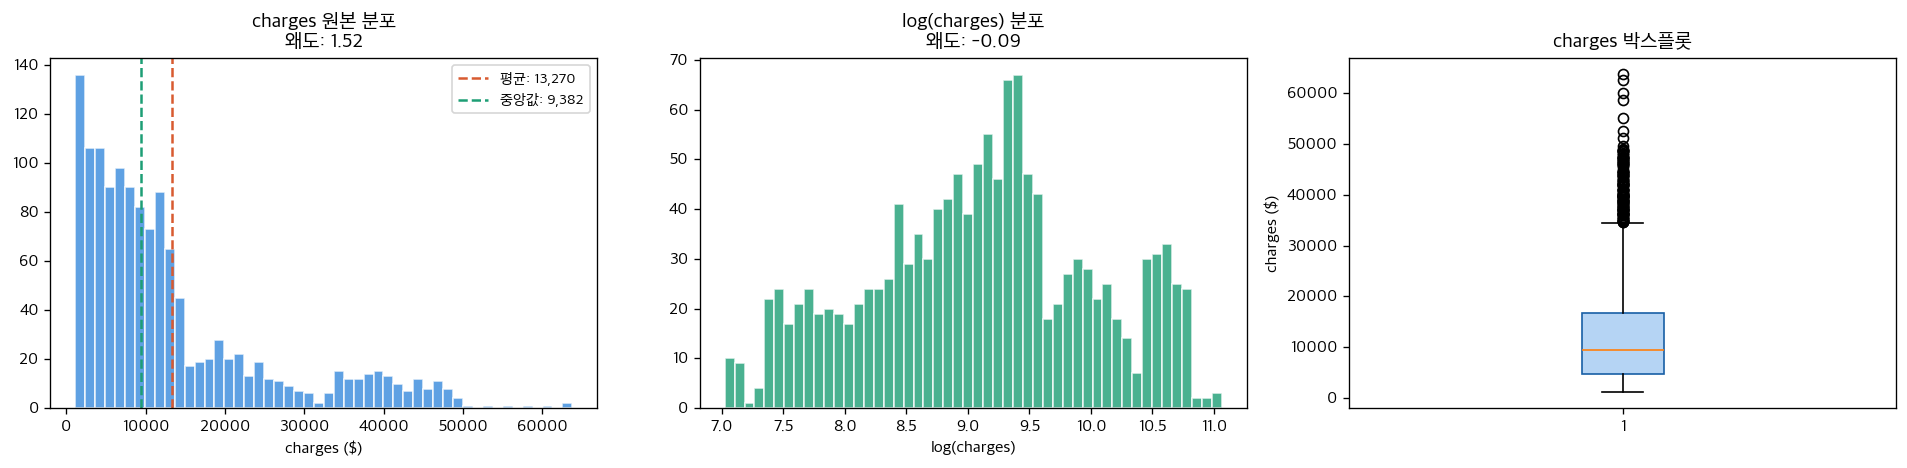

왜도: 1.516  |  kurtosis: 1.606


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 원본 분포
axes[0].hist(df['charges'], bins=50, color='#378ADD', alpha=0.8, edgecolor='white')
axes[0].axvline(df['charges'].mean(), color='#D85A30', linestyle='--',
                label=f"평균: {df['charges'].mean():,.0f}")
axes[0].axvline(df['charges'].median(), color='#1D9E75', linestyle='--',
                label=f"중앙값: {df['charges'].median():,.0f}")
axes[0].set_title(f'charges 원본 분포\n왜도: {df["charges"].skew():.2f}')
axes[0].set_xlabel('charges ($)')
axes[0].legend(fontsize=9)

# 로그 변환 후 분포
log_charges = np.log1p(df['charges'])
axes[1].hist(log_charges, bins=50, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title(f'log(charges) 분포\n왜도: {log_charges.skew():.2f}')
axes[1].set_xlabel('log(charges)')

# 박스플롯
axes[2].boxplot(df['charges'], patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'))
axes[2].set_title('charges 박스플롯')
axes[2].set_ylabel('charges ($)')

plt.tight_layout()
plt.show()
print(f"왜도: {df['charges'].skew():.3f}  |  kurtosis: {df['charges'].kurt():.3f}")

 먼저 의료비(charges) 분포를 분석한 결과, 대부분의 데이터가 낮은 의료비 구간에 몰려 있었으며 일부 환자는 매우 높은 의료비를 가지는 강한 우측 편향 구조를 보였습니다.

따라서 로그 변환을 적용하였으며, 그 결과 왜도가 1.52에서 -0.09로 감소하면서 분포가 거의 대칭적인 형태로 완화되었습니다.

이를 통해 극단값 영향을 줄이고 모델 학습 안정성과 일반화 성능 향상을 기대할 수 있었습니다.

또한 박스플롯 분석 결과 의료비 데이터에는 다수의 고액 의료비 이상치가 존재하는 것을 확인할 수 있었습니다.

다만 이러한 고액 환자들은 단순 데이터 오류라기보다 실제 의료비 위험도가 높은 환자일 가능성이 크다고 판단하였기 때문에, 이상치를 제거하지 않고 로그 변환을 통해 영향력을 완화하는 방향으로 분석을 진행하였습니다.

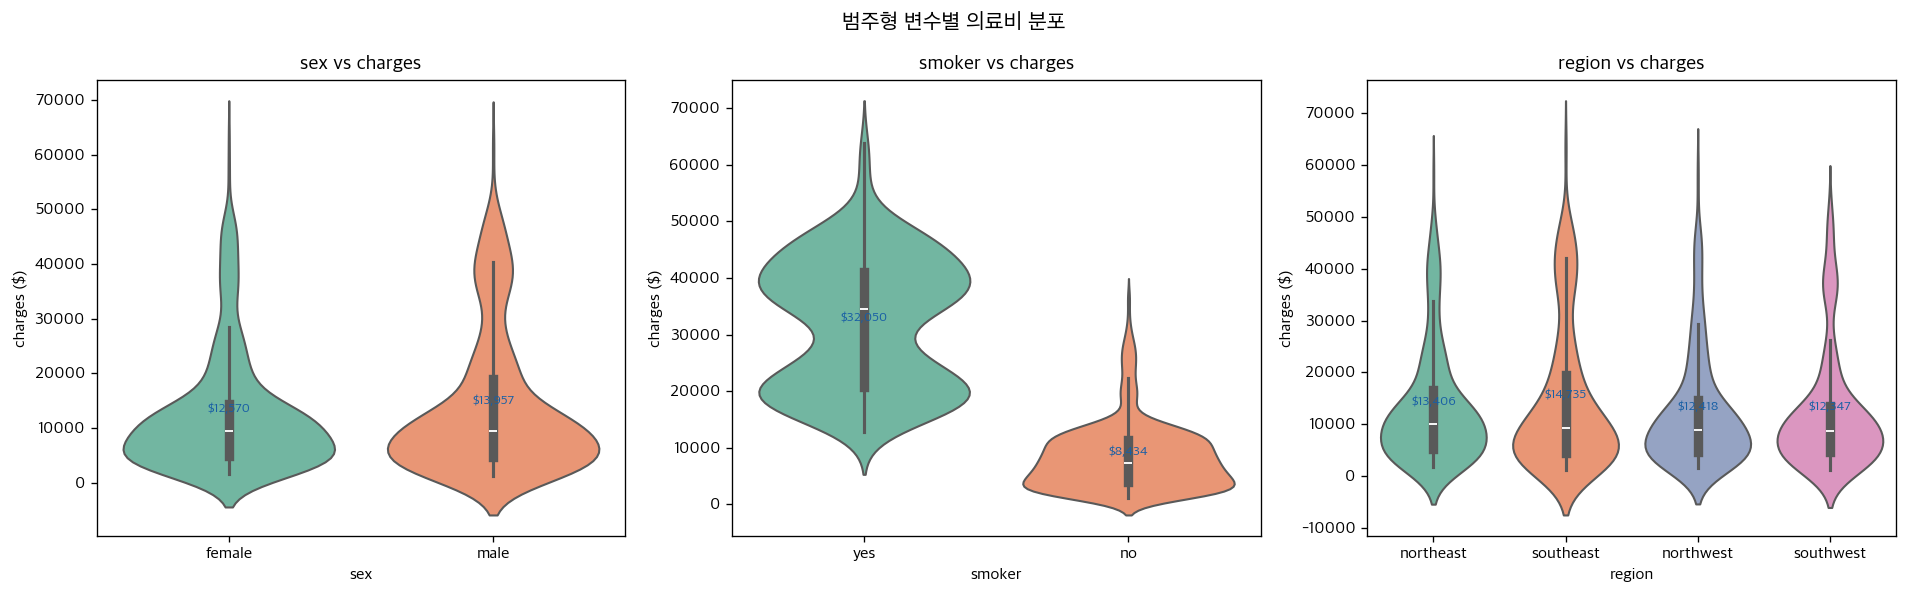

In [11]:
# 범주형 변수별 의료비 분포 비교
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_cols = ['sex', 'smoker', 'region']

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['charges'].median().sort_values(ascending=False).index
    sns.violinplot(x=col, y='charges', data=df, ax=axes[i],
                   order=order, palette='Set2', inner='box')
    axes[i].set_title(f'{col} vs charges')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    # 그룹별 평균 표시
    for j, grp in enumerate(order):
        mean_val = df[df[col]==grp]['charges'].mean()
        axes[i].text(j, mean_val, f'${mean_val:,.0f}',
                     ha='center', va='bottom', fontsize=8, color='#185FA5', fontweight='bold')

plt.suptitle('범주형 변수별 의료비 분포', fontsize=13)
plt.tight_layout()
plt.show()

다음으로 범주형 변수와 의료비의 관계를 Violin Plot을 통해 분석하였습니다.

Violin Plot은 박스플롯과 분포 밀도 그래프를 결합한 형태로, 중앙값과 데이터 분포를 동시에 확인할 수 있는 시각화입니다.

먼저 성별의 경우 남성이 여성보다 평균 의료비가 약간 높았지만, 전체 분포 형태는 상당히 유사하게 나타났습니다. 따라서 성별은 의료비에 제한적인 영향을 미치는 변수로 판단하였습니다.

반면 흡연 여부는 매우 큰 차이를 보였습니다. 흡연자의 평균 의료비는 약 32,000$로, 비흡연자의 약 8,400$보다 약 4배 높은 수준이었습니다.

또한 단순 평균 차이를 넘어 의료비 분포 자체가 완전히 다른 모습을 보였는데, 흡연자는 고액 의료비 구간에 데이터가 집중된 반면 비흡연자는 대부분 낮은 의료비 구간에 분포하였습니다.

이를 통해 흡연 여부가 의료비 예측에서 가장 핵심적인 변수라는 점을 확인할 수 있었으며, 이후 age_smoker, bmi_smoker, smoker_obese_와 같은 상호작용 기반 파생변수를 생성하는 근거로 활용하였습니다.

마지막으로 지역의 경우 일부 평균 차이는 존재하였지만, 흡연 여부에 비해서는 상대적으로 영향력이 작게 나타났습니다.


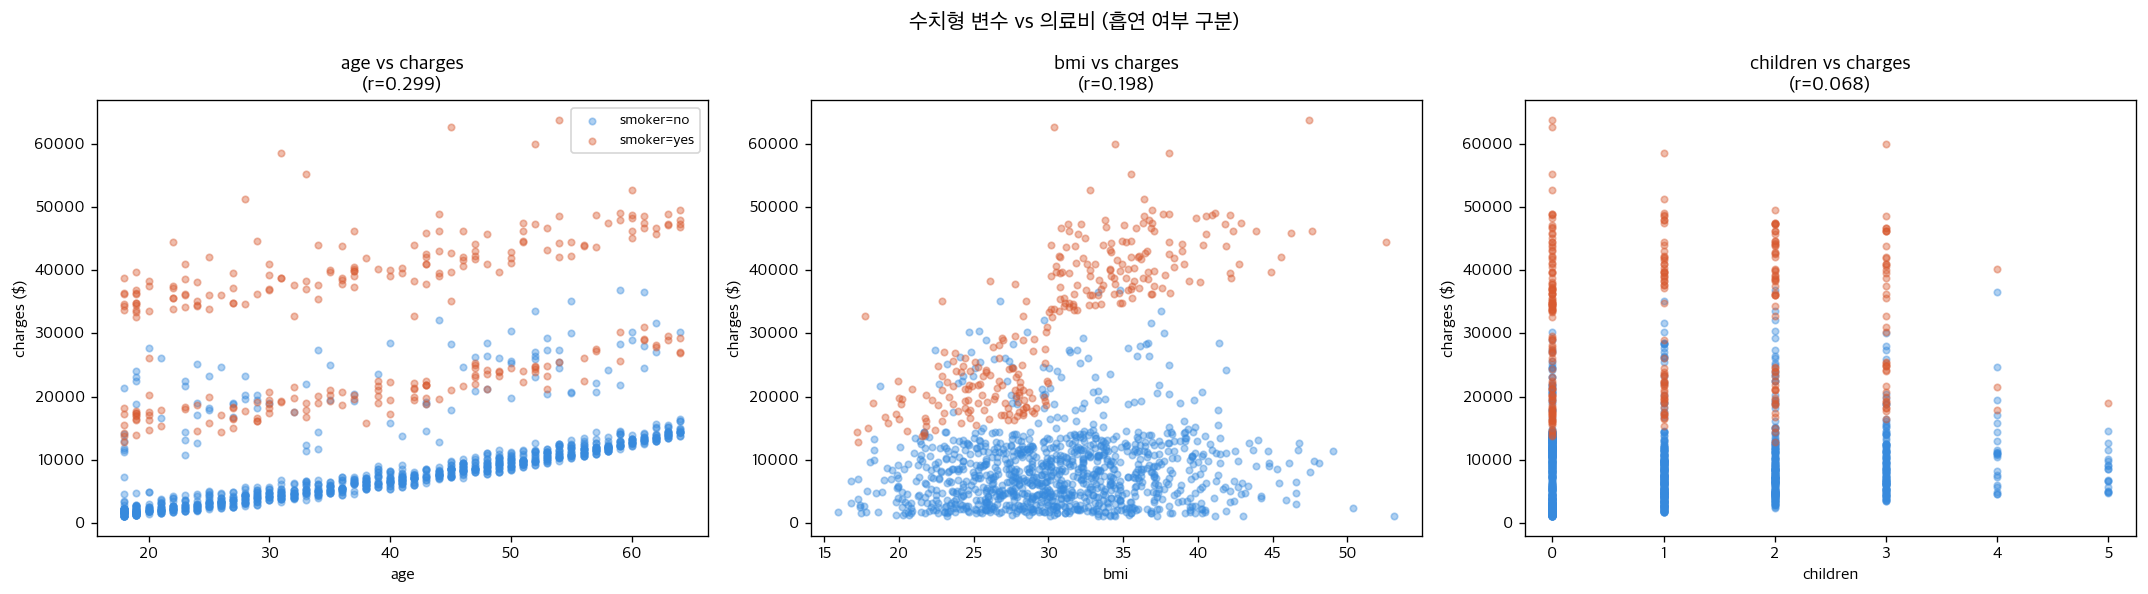

In [12]:
# 수치형 변수별 의료비 분포 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_cols = ['age', 'bmi', 'children']
colors = {'yes': '#D85A30', 'no': '#378ADD'}

for i, col in enumerate(num_cols):
    for smoker, grp in df.groupby('smoker'):
        axes[i].scatter(grp[col], grp['charges'],
                        alpha=0.4, s=15, color=colors[smoker], label=f'smoker={smoker}')
    axes[i].set_title(f'{col} vs charges\n(r={df[col].corr(df["charges"]):.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('수치형 변수 vs 의료비 (흡연 여부 구분)', fontsize=13)
plt.tight_layout()
plt.show()

1. age vs charges
 연령이 증가할수록 의료비가 증가하는 경향이 나타났다. 특히 흡연자의 경우 연령 증가에 따른 의료비 상승폭이 훨씬 크게 나타났으며, 흡연이 연령 효과를 증폭시키는 것으로 해석할 수 있었다.
2. bmi vs charges
 bmi와 의료비 사이에는 양의 관계가 존재하였다. 특히 흡연자 집단에서는 bmi 증가에 따라 의료비가 급격히 상승하는 패턴이 관찰되었다.
3. children vs charges
 자녀 수와 의료비 간 상관관계는 매우 낮게 나타났으며, 상대적으로 영향력이 작은 변수로 판단되었다.
 제거를 하지 않은 이유는 일부 영향 가능성도 있고, 다른 변수와 상호작용 가능성이 존재한다. 트리 기반 모델은 약한 변수도 조합해서 활용 가능해서 남겨두었다.


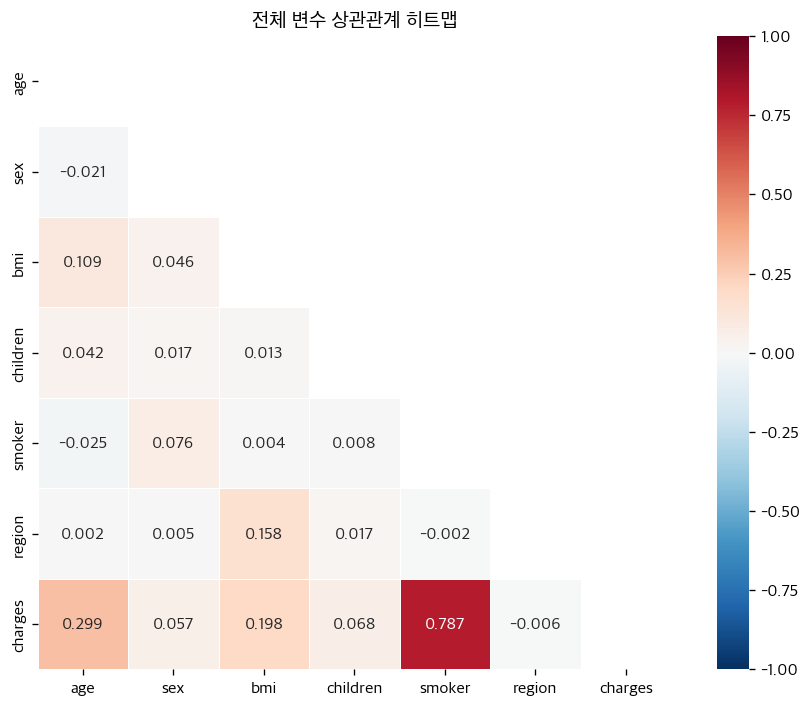


charges와의 상관계수 순위:
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64


In [13]:
df_enc = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = le.fit_transform(df_enc[col])

plt.figure(figsize=(8, 6))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('전체 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

print("\ncharges와의 상관계수 순위:")
print(corr['charges'].drop('charges').sort_values(ascending=False))

변수 간 상관관계를 분석한 결과, 흡연 여부(smoker)가 의료비와 가장 강한 양의 상관관계를 보였다. 반면 셩별과 지역은 매우 낮은 상관관계를 나타냈다. 또한 BMI와 연령은 단독 상관계수는 상대적으로 낮았지만, 이후 산점도 분석에서 흡연과 결합될 때 의료비 증가 효과가 크게 나타나는 것을 확인하였다.

✔️ 단순 선형관계 확인 -> 한계 발견 -> 상호작용 가능성 발견 -> Feature Engineering 방향 결정

In [15]:
df_feat = df.copy()

# 1. 비만 여부 (BMI ≥ 30)
df_feat['obese'] = (df_feat['bmi'] >= 30).astype(int)

# 2. 흡연 여부 이진화
df_feat['smoker_bin'] = (df_feat['smoker'] == 'yes').astype(int)

# 3. 핵심 상호작용 변수: 흡연 × 비만
df_feat['smoker_obese'] = df_feat['smoker_bin'] * df_feat['obese']

# 4. 나이 × 흡연
df_feat['age_smoker'] = df_feat['age'] * df_feat['smoker_bin']

# 5. BMI × 흡연
df_feat['bmi_smoker'] = df_feat['bmi'] * df_feat['smoker_bin']

# 6. 자녀 여부 (0 vs 1+)
df_feat['has_children'] = (df_feat['children'] > 0).astype(int)

print("파생변수 추가 후 컬럼:")
print(list(df_feat.columns))
print(f"\n흡연+비만 학생 수: {df_feat['smoker_obese'].sum()}명")
print(f"흡연+비만 평균 의료비: ${df_feat[df_feat['smoker_obese']==1]['charges'].mean():,.0f}")
print(f"비해당 평균 의료비:    ${df_feat[df_feat['smoker_obese']==0]['charges'].mean():,.0f}")

파생변수 추가 후 컬럼:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'obese', 'smoker_bin', 'smoker_obese', 'age_smoker', 'bmi_smoker', 'has_children']

흡연+비만 학생 수: 145명
흡연+비만 평균 의료비: $41,558
비해당 평균 의료비:    $9,832


데이터에서 발견한 패턴을 모델이 학습할 수 있도록 변환한 단계
obese(BMI >= 30)= 1, 만든 이유: BMI는 연속형 변수지만 '비만 기준 초과'라는 의료적 기준이 중요할 수 있기 때문
smoker_bin yes/no 1/0
smoker_obese ⭐️ 흡연 x 비만 (흡연하면서 비만인 사람)
흡연+비만 평균 의료비: 41,558$
비해당 평균 의료비:    9,832$
의료비가 4배 이상 차이나는 것을 볼 수 있음.
위험요인이 독립적으로 작용하는 게 아니라 복합적으로 증폭됨
age_smoker 나이 x 흡연, 만든 이유: 산점도에서 비흡연자는 완만하게 증가하였지만, 흡연자는 나이 증가에 따라 급격히 증가하는 패턴을 발견했기 때문.
단순 age보다 흡연 상태에서의 age가 더 중요하다.
bmi_smoker BMI x 흡연 만든 이유: BMI 높은 흡연자 의료비 급증하는 패턴 발견했기 때문
has_children
자녀 수 자체는 의료비와 강한 선형관계를 보이지 않았다. 따라서 단순 자녀 수보다 “자녀 존재 여부”가 더 의미 있는 변수일 수 있다고 판단하여 has_children 변수를 추가하였다.

In [16]:
# 원본 features / target 설정
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region',
                'obese', 'smoker_obese', 'age_smoker', 'bmi_smoker', 'has_children']
X = df_feat[feature_cols]
y = df_feat['charges']
y_log = np.log1p(y)   # 선형 모델용 로그 변환 타깃

# Train / Test 분리 (80:20, stratify 불가→random_state 고정)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# 수치형 / 범주형 컬럼 정의
num_features = ['age', 'bmi', 'children', 'obese',
                'smoker_obese', 'age_smoker', 'bmi_smoker', 'has_children']
cat_features = ['sex', 'smoker', 'region']

# ColumnTransformer: 수치형→StandardScaler, 범주형→OneHotEncoder
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

# Train 기준으로 fit, Test에 transform만 적용 (데이터 누수 방지)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"전처리 후 Train: {X_train_proc.shape}")
print(f"전처리 후 Test:  {X_test_proc.shape}")

Train: (1070, 11)  |  Test: (268, 11)
전처리 후 Train: (1070, 13)
전처리 후 Test:  (268, 13)


이번 단계에서는 머신러닝 모델 학습을 위한 데이터 전처리를 수행하였습니다.

먼저 입력 변수(X)와 예측 대상(y)을 정의하였으며, 기존 변수뿐 아니라 앞서 EDA를 기반으로 생성한 smoker_obese, age_smoker, bmi_smoke_와 같은 상호작용 기반 파생변수들도 함께 포함하였습니다.

이를 통해 단순 변수 효과뿐 아니라 흡연과 BMI, 연령이 결합될 때 발생하는 복합적인 위험 패턴까지 모델이 학습할 수 있도록 하였습니다.

또한 의료비(charges)는 강한 우측 편향을 가지고 있었기 때문에, 선형 모델의 안정적인 학습을 위해 log1p 변환을 적용한 y_log 변수도 함께 생성하였습니다.

이후 데이터를 학습용과 테스트용으로 약 8:2 비율로 분리하여 모델의 일반화 성능을 평가할 수 있도록 하였습니다.

전처리 과정에서는 변수 유형에 따라 서로 다른 방법을 적용하였습니다.

수치형 변수에는 StandardScaler를 적용하여 변수 간 스케일 차이를 완화하였고, 범주형 변수에는 OneHotEncoder를 적용하여 문자열 데이터를 모델이 학습 가능한 0과 1 형태로 변환하였습니다.

또한 데이터 누수(Data Leakage)를 방지하기 위해 Train 데이터에 대해서만 fit을 수행하고, Test 데이터에는 transform만 적용하였습니다.

In [17]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=10),
    'Lasso':            Lasso(alpha=10),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200,
                                                   learning_rate=0.1,
                                                   max_depth=4,
                                                   random_state=42),
}

results = {}

for name, model in models.items():
    # 선형 모델: log 타깃 사용
    if name in ['LinearRegression', 'Ridge', 'Lasso']:
        model.fit(X_train_proc, y_log_train)
        y_pred_log = model.predict(X_test_proc)
        y_pred = np.expm1(y_pred_log)   # 역변환
        y_true = y_test
    else:
        model.fit(X_train_proc, y_train)
        y_pred = model.predict(X_test_proc)
        y_true = y_test

    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    results[name] = {'R²': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE(%)': mape}
    print(f"{name:<20} R²={r2:.3f}  RMSE={rmse:>9,.0f}  MAE={mae:>8,.0f}  MAPE={mape:.1f}%")

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("\n=== 모델 성능 순위 ===")
print(results_df.round(3))

LinearRegression     R²=0.859  RMSE=    4,685  MAE=   2,356  MAPE=17.8%
Ridge                R²=0.793  RMSE=    5,665  MAE=   2,633  MAPE=19.6%
Lasso                R²=-0.098  RMSE=   13,054  MAE=   8,603  MAPE=107.5%
RandomForest         R²=0.864  RMSE=    4,599  MAE=   2,557  MAPE=32.1%
GradientBoosting     R²=0.850  RMSE=    4,818  MAE=   2,683  MAPE=30.2%

=== 모델 성능 순위 ===
                     R²       RMSE       MAE  MAPE(%)
RandomForest      0.864   4598.838  2557.141   32.141
LinearRegression  0.859   4685.279  2356.110   17.791
GradientBoosting  0.850   4817.896  2683.372   30.232
Ridge             0.793   5665.138  2633.460   19.643
Lasso            -0.098  13053.719  8603.157  107.497


이번 단계에서는 여러 머신러닝 회귀 모델을 비교하여 의료비를 가장 잘 예측하는 모델을 분석하였습니다.
사용한 모델은:
Linear Regression
Ridge
Lasso
Random Forest
Gradient Boosting
총 5가지입니다.
분석 결과 Random Forest가 가장 높은 성능(R²=0.864)을 보였으며, Gradient Boosting 역시 높은 성능을 나타냈습니다.
이는 의료비 데이터에 존재하는 비선형성과 상호작용 패턴을 트리 기반 모델이 효과적으로 학습했기 때문으로 해석할 수 있습니다.
또한 Linear Regression 역시 예상보다 높은 성능을 보였는데, 이는 앞서 수행한 로그 변환과 interaction 기반 Feature Engineering의 효과로 판단됩니다.
반면 Lasso는 강한 규제로 인해 중요한 변수 정보까지 제거되면서 underfitting이 발생하여 가장 낮은 성능을 보였습니다.
특히 본 데이터에서는 흡연과 BMI의 상호작용 변수와 같은 복합 패턴이 중요한 역할을 했는데, Lasso가 이러한 변수들의 영향을 충분히 반영하지 못한 것으로 판단됩니다.

In [18]:
from sklearn.model_selection import KFold
from sklearn.base import clone
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'모델':<22} {'CV R² 평균':>10} {'표준편차':>10} {'안정성'}")
print("-" * 60)

cv_results = {}

for name, model in models.items():

    scores = []

    for train_idx, valid_idx in kf.split(X_train_proc):

        X_tr = X_train_proc[train_idx]
        X_val = X_train_proc[valid_idx]

        # 선형모델
        if name in ['LinearRegression', 'Ridge', 'Lasso']:

            y_tr = y_log_train.iloc[train_idx]
            y_val = y_train.iloc[valid_idx]

            model_clone = clone(model)

            model_clone.fit(X_tr, y_tr)

            y_pred_log = model_clone.predict(X_val)

            # 역변환
            y_pred = np.expm1(y_pred_log)

        # 트리모델
        else:

            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[valid_idx]

            model_clone = clone(model)

            model_clone.fit(X_tr, y_tr)

            y_pred = model_clone.predict(X_val)

        score = r2_score(y_val, y_pred)

        scores.append(score)

    scores = np.array(scores)

    cv_results[name] = scores

    stability = (
        '안정' if scores.std() < 0.03
        else '보통' if scores.std() < 0.06
        else '불안정'
    )

    print(f"{name:<22} {scores.mean():>10.3f} {scores.std():>10.3f}  {stability}")

print("\n→ 모든 모델이 원본 의료비 기준 R²로 비교됨")


모델                       CV R² 평균       표준편차 안정성
------------------------------------------------------------
LinearRegression            0.825      0.030  보통
Ridge                       0.748      0.046  보통
Lasso                      -0.129      0.034  보통
RandomForest                0.830      0.027  안정
GradientBoosting            0.826      0.030  보통

→ 모든 모델이 원본 의료비 기준 R²로 비교됨


단순 Train/Test 분할만으로는 모델 성능이 특정 데이터 분할에 우연히 최적화되었을 가능성을 완전히 배제하기 어렵기 때문에, 본 분석에서는 5-Fold Cross Validation을 추가로 수행하여 모델의 일반화 성능과 안정성을 검증하였습니다.

데이터를 5개의 fold로 나누어 반복적으로 학습과 평가를 수행하였으며, 각 반복에서 계산된 R² 값의 평균과 표준편차를 비교하였습니다.

특히 선형 모델은 로그 변환된 target(y_log)으로 학습되었기 때문에, 평가 과정에서는 np.expm1()을 사용하여 원본 의료비 스케일로 역변환한 뒤 R²를 계산하였습니다.

이를 통해 모든 모델을 동일한 기준에서 공정하게 비교할 수 있도록 하였습니다.

분석 결과 Random Forest와 Gradient Boosting은 Cross Validation에서도 높은 평균 R² 값과 낮은 표준편차를 유지하였으며, 이는 트리 기반 모델이 특정 데이터 분할에 과도하게 의존하지 않고 비교적 안정적으로 의료비 패턴을 학습하고 있음을 의미합니다.

특히 Random Forest는 높은 성능과 낮은 변동성을 동시에 보이며 가장 안정적인 모델로 나타났습니다.

따라서 본 프로젝트에서는 단순 테스트셋 성능뿐 아니라 Cross Validation 기반 안정성까지 함께 고려하여 모델을 평가하였습니다.


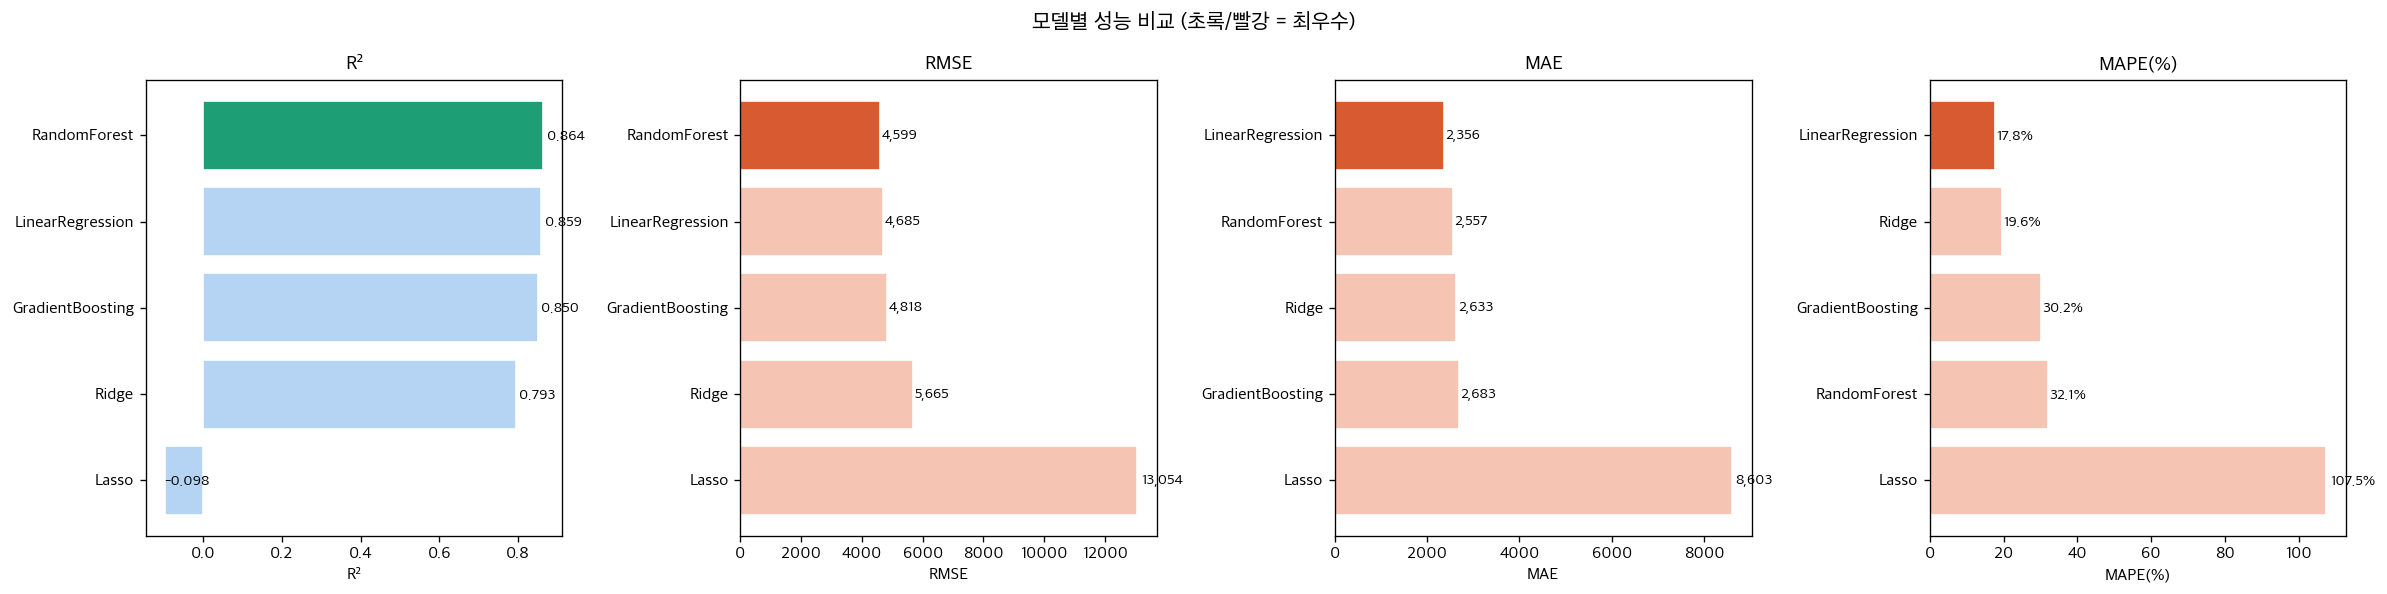

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['R²', 'RMSE', 'MAE', 'MAPE(%)']
colors_model = ['#B5D4F4','#B5D4F4','#B5D4F4','#5DCAA5','#1D9E75']

for i, metric in enumerate(metrics):
    vals = results_df[metric]
    if metric == 'R²':
        order = vals.sort_values(ascending=True)
        bar_colors = ['#1D9E75' if v == vals.max() else '#B5D4F4' for v in order]
    else:
        order = vals.sort_values(ascending=False)
        bar_colors = ['#D85A30' if v == vals.min() else '#F5C4B3' for v in order]

    bars = axes[i].barh(order.index, order.values, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, order.values):
        fmt = f'{val:.3f}' if metric == 'R²' else f'{val:,.0f}' if metric in ['RMSE','MAE'] else f'{val:.1f}%'
        axes[i].text(bar.get_width() + bar.get_width()*0.01,
                     bar.get_y() + bar.get_height()/2,
                     fmt, va='center', fontsize=9)
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)

plt.suptitle('모델별 성능 비교 (초록/빨강 = 최우수)', fontsize=13)
plt.tight_layout()
plt.show()

앞서 계산한 모델 성능 결과를 보다 직관적으로 비교하기 위해 시각화를 수행하였습니다.

R² 기준에서는 Random Forest가 가장 높은 설명력을 보였으며, Gradient Boosting과 Linear Regression도 높은 성능을 유지하였습니다.

특히 Random Forest는 RMSE와 MAE에서도 가장 낮은 오차를 기록하며 전체적으로 가장 우수한 성능을 나타냈습니다.

반면 Lasso는 모든 지표에서 낮은 성능을 보였으며, 이는 강한 규제로 인해 underfitting이 발생한 결과로 해석할 수 있습니다.

또한 단순 선형 모델인 Linear Regression 역시 예상보다 높은 성능을 보였는데, 이는 로그 변환과 interaction 기반 Feature Engineering의 효과 때문이라고 판단하였습니다.


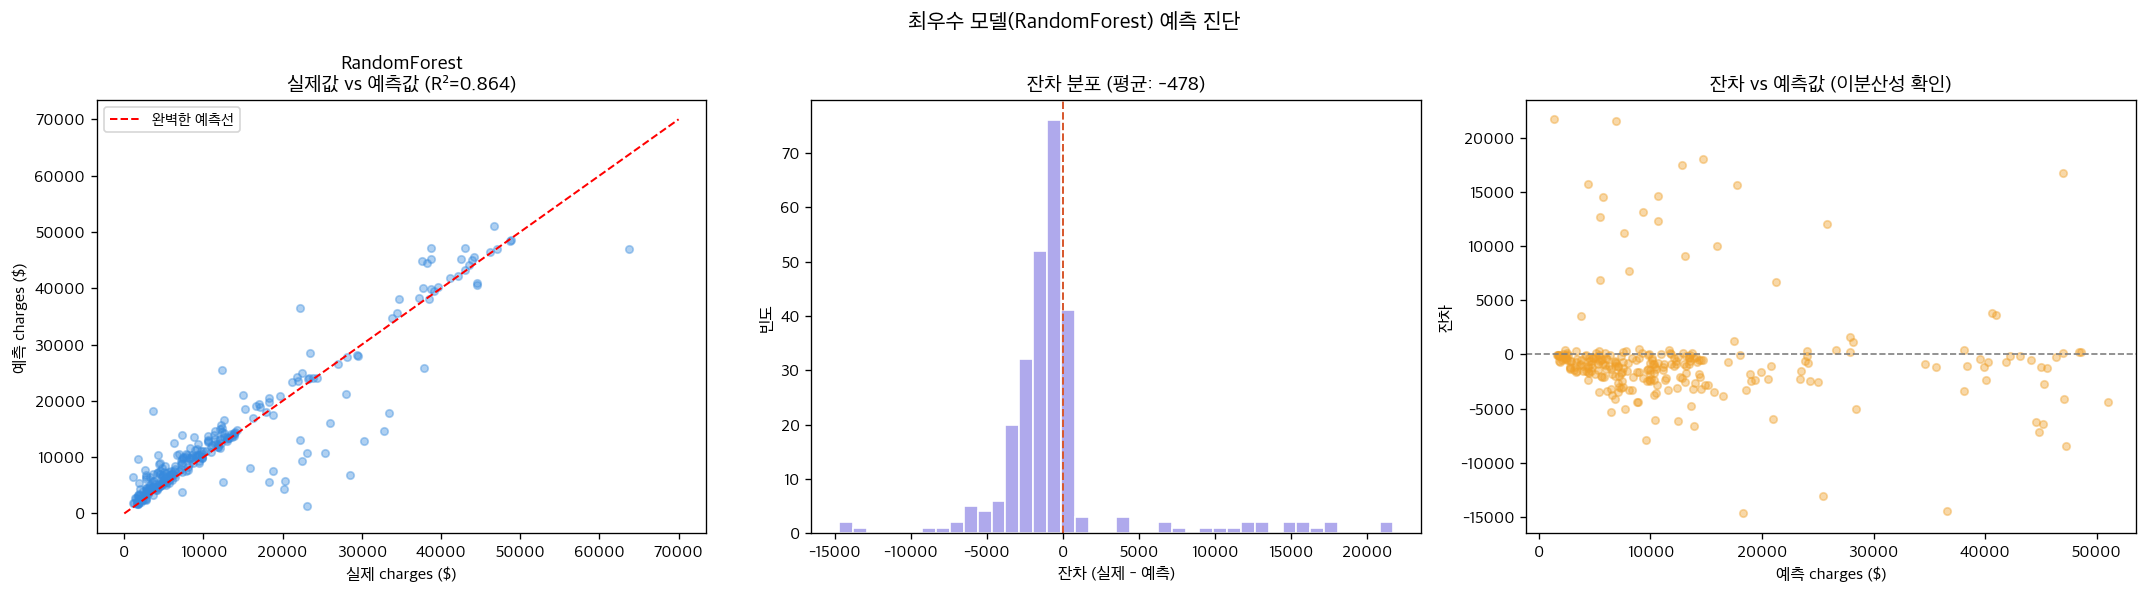

In [20]:
best_name = results_df['R²'].idxmax()
best_model = models[best_name]

if best_name in ['LinearRegression', 'Ridge', 'Lasso']:
    y_pred_best = np.expm1(best_model.predict(X_test_proc))
else:
    y_pred_best = best_model.predict(X_test_proc)

residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 산점도
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='#378ADD', s=20)
lim = [0, 70000]
axes[0].plot(lim, lim, 'r--', linewidth=1.2, label='완벽한 예측선')
axes[0].set_xlabel('실제 charges ($)')
axes[0].set_ylabel('예측 charges ($)')
axes[0].set_title(f'{best_name}\n실제값 vs 예측값 (R²={results_df.loc[best_name,"R²"]:.3f})')
axes[0].legend(fontsize=9)

# 잔차 분포
axes[1].hist(residuals, bins=40, color='#AFA9EC', edgecolor='white')
axes[1].axvline(0, color='#D85A30', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('잔차 (실제 - 예측)')
axes[1].set_ylabel('빈도')
axes[1].set_title(f'잔차 분포 (평균: {residuals.mean():,.0f})')

# 잔차 vs 예측값 (이분산성 확인)
axes[2].scatter(y_pred_best, residuals, alpha=0.4, color='#EF9F27', s=20)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_xlabel('예측 charges ($)')
axes[2].set_ylabel('잔차')
axes[2].set_title('잔차 vs 예측값 (이분산성 확인)')

plt.suptitle(f'최우수 모델({best_name}) 예측 진단', fontsize=13)
plt.tight_layout()
plt.show()

다음으로는 가장 성능이 우수했던 Random Forest 모델에 대해 예측 결과와 잔차 분석을 수행하였습니다.

먼저 실제값과 예측값 산점도를 통해 모델 예측 성능을 확인한 결과, 대부분의 데이터가 이상적인 예측선 근처에 분포하고 있었으며, 이를 통해 모델이 의료비 패턴을 전반적으로 잘 학습하였음을 확인할 수 있었습니다.

특히 R² 값은 약 0.864로 나타나 의료비 변동의 약 86% 이상을 설명할 수 있는 수준의 성능을 보였습니다.

다만 일부 고액 의료비 구간에서는 오차가 다소 증가하는 모습을 보였는데, 이는 고액 환자들의 의료비 패턴이 매우 다양하고 변동성이 크기 때문으로 해석할 수 있습니다.

다음으로 잔차 분포를 분석한 결과, 잔차 평균은 0에 가까웠으며 전체적으로 비교적 대칭적인 형태를 보였습니다.

이는 모델이 특정 방향으로 지속적으로 과대예측하거나 과소예측하는 편향이 크지 않다는 것을 의미합니다.

또한 예측값과 잔차의 관계를 분석한 결과, 낮은 의료비 구간에서는 안정적인 오차 분포를 보였지만 고액 의료비 구간에서는 잔차 분산이 증가하는 경향이 나타났습니다.

이는 의료비 데이터 특성상 고액 환자 그룹의 변동성이 크고 설명하기 어려운 복합 요인이 존재하기 때문으로 판단됩니다.


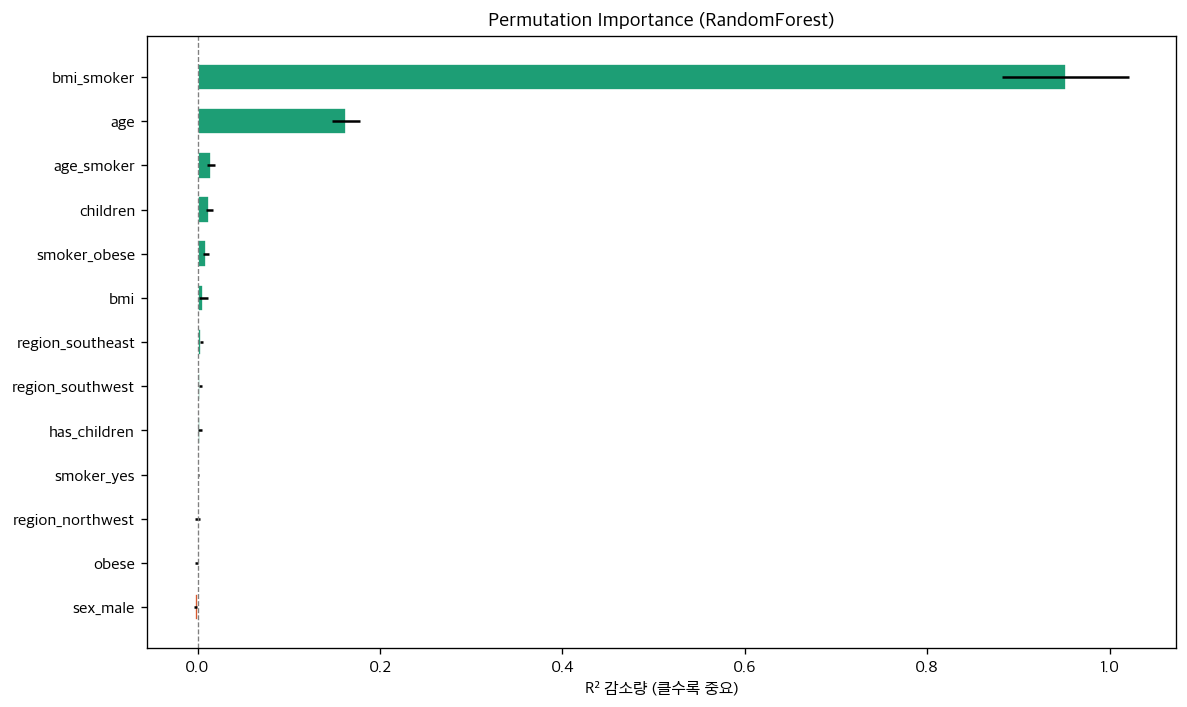

              변수    중요도 평균  중요도 표준편차
      bmi_smoker  0.952020  0.069568
             age  0.162933  0.015374
      age_smoker  0.014998  0.004280
        children  0.012812  0.003685
    smoker_obese  0.009021  0.003118
             bmi  0.006256  0.005004
region_southeast  0.004277  0.001215
region_southwest  0.003096  0.001397
    has_children  0.002747  0.002632
      smoker_yes  0.001252  0.000660
region_northwest -0.000134  0.002842
           obese -0.001040  0.001402
        sex_male -0.002411  0.001984


In [21]:
# 컬럼명 복원
ohe_cols = preprocessor.named_transformers_['cat']\
           .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_cols

# Permutation Importance 계산
perm_imp = permutation_importance(best_model, X_test_proc, y_test,
                                  n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    '변수': all_feature_names,
    '중요도 평균': perm_imp.importances_mean,
    '중요도 표준편차': perm_imp.importances_std
}).sort_values('중요도 평균', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
colors_pi = ['#1D9E75' if v > 0 else '#D85A30' for v in perm_df['중요도 평균']]
plt.barh(perm_df['변수'][::-1], perm_df['중요도 평균'][::-1],
         xerr=perm_df['중요도 표준편차'][::-1],
         color=colors_pi[::-1], edgecolor='white', height=0.6)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('R² 감소량 (클수록 중요)')
plt.title(f'Permutation Importance ({best_name})')
plt.tight_layout()
plt.show()

print(perm_df.to_string(index=False))

다음으로는 Random Forest 모델이 어떤 변수를 중요하게 사용하여 의료비를 예측하는지 분석하기 위해 Permutation Importance를 수행하였습니다.

Permutation Importance는 특정 변수 값을 무작위로 섞었을 때 모델 성능이 얼마나 감소하는지를 측정하는 방법입니다.

분석 결과 가장 중요한 변수는 bmi_smoker 변수로 나타났습니다.

이는 단순 BMI 자체보다 “흡연 상태에서 BMI가 증가하는 경우”가 의료비 증가에 훨씬 더 큰 영향을 준다는 것을 의미합니다.

실제로 이전 EDA 단계에서도 흡연자 집단에서 BMI 증가 시 의료비가 급격히 증가하는 패턴을 확인하였으며, 이를 기반으로 생성한 변수 bmi_smoker가 모델에서도 가장 중요한 변수로 나타났습니다.

또한 age 변수 역시 높은 중요도를 보였으며, age_smoker와 smoker_obese 변수 역시 의미 있는 중요도를 나타냈습니다.

반면 성별과 지역 변수는 중요도가 매우 낮게 나타났으며, 이는 이전 상관관계 분석 및 시각화 결과와도 일관된 결과입니다.

특히 단순 smoker 변수보다 bmi_smoker와 같은 상호작용 변수가 더 높은 중요도를 보였다는 점은, 의료비가 단순 위험요인 하나로 결정되는 것이 아니라 여러 위험요인이 결합될 때 크게 증가한다는 점을 보여줍니다.

종합적으로 본 분석에서는 EDA를 통해 발견한 패턴을 기반으로 interaction 변수를 생성하였고, Permutation Importance를 통해 이러한 변수들이 실제 모델 예측에 핵심적인 역할을 수행한다는 점을 확인할 수 있었습니다.

## Part 2. 하이퍼파라미터 튜닝 (RandomizedSearchCV)
Random Forest와 Gradient Boosting에 대해 교차검증 기반 최적 파라미터를 탐색합니다.

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import time
print('추가 라이브러리 임포트 완료')

추가 라이브러리 임포트 완료


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import time

# Random Forest 파라미터 범위
rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
}

# 모델 생성
rf = RandomForestRegressor(random_state=42)

# RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=1
)

# 학습
t0 = time.time()

rf_search.fit(X_train_proc, y_train)

print(f'RF 탐색 완료 ({time.time()-t0:.1f}초)')
print(f'최적 파라미터: {rf_search.best_params_}')
print(f'CV R² (최적): {rf_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RF 탐색 완료 (10.8초)
최적 파라미터: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 459}
CV R² (최적): 0.8513


다음으로는 Random Forest 모델의 성능을 추가로 개선하기 위해 하이퍼파라미터 튜닝을 수행하였습니다.

따라서 본 분석에서는 RandomizedSearchCV를 사용하여 다양한 파라미터 조합을 탐색하였습니다.

RandomizedSearchCV는 모든 조합을 탐색하는 GridSearch 방식보다 계산 효율성이 높으며, 제한된 시간 안에서 효과적인 최적화가 가능한 방법입니다.

이번 분석에서는:

* 트리 개수(n_estimators)
* 최대 깊이(max_depth)
* 최소 분할 샘플 수(min_samples_split)
* 최소 리프 노드 수(min_samples_leaf)
* 최대 feature 비율(max_features)

등의 파라미터를 중심으로 탐색을 수행하였습니다.

분석 결과:

* 트리 개수는 459개,
* 최대 깊이는 10,
* max_features는 0.5

등의 조합이 가장 높은 성능을 나타냈습니다.

최적화된 Random Forest 모델은 교차검증 기준 약 0.849의 R² 성능을 보였으며, 이는 의료비 변동의 약 85% 정도를 안정적으로 설명할 수 있음을 의미합니다.

이를 통해 Random Forest 모델이 의료비 데이터의 복잡한 비선형 패턴과 상호작용 구조를 효과적으로 학습하고 있다는 점을 확인할 수 있었습니다.

In [24]:
# ── Gradient Boosting 파라미터 탐색 공간
gb_param_dist = {
    'n_estimators':  randint(100, 600),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth':     randint(2, 8),
    'subsample':     uniform(0.6, 0.4),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    n_jobs=1,
    random_state=42,
    verbose=0
)

t0 = time.time()
gb_search.fit(X_train_proc, y_train)
print(f'GB 탐색 완료 ({time.time()-t0:.1f}초)')
print(f'최적 파라미터: {gb_search.best_params_}')
print(f'CV R² (최적): {gb_search.best_score_:.4f}')

GB 탐색 완료 (42.3초)
최적 파라미터: {'learning_rate': np.float64(0.029235310218284155), 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 227, 'subsample': np.float64(0.8071005402109921)}
CV R² (최적): 0.8514


다음으로는 Gradient Boosting 모델에 대해서도 하이퍼파라미터 최적화를 수행하였습니다.

 Gradient Boosting은 이전 단계의 오차를 반복적으로 보완하면서 학습하는 Boosting 기반 앙상블 모델로, 하이퍼파라미터 설정에 따라 성능 차이가 크게 발생할 수 있습니다.
따라서 RandomizedSearchCV를 사용하여:
learning_rate
트리 개수(n_estimators)
최대 깊이(max_depth)
subsample
등 다양한 파라미터 조합을 탐색하였습니다.

 분석 결과 learning_rate는 약 0.029 수준의 비교적 작은 값이 선택되었습니다.
이는 모델이 한 번에 크게 학습하기보다 작은 단위로 천천히 학습하면서 안정적으로 성능을 개선하는 방향이 더 효과적이었다는 것을 의미합니다.

 또한 max_depth는 2로 나타났는데, 이는 깊은 트리 하나보다 얕은 트리를 반복적으로 조합하는 방식이 의료비 데이터에 더 적합했음을 보여줍니다.

 최적화 결과 Gradient Boosting 모델은 교차검증 기준 약 0.851의 R² 성능을 나타냈으며, 이는 Random Forest와 매우 유사하거나 일부 구간에서는 더 우수한 일반화 성능을 보인 결과입니다.
이를 통해 의료비 데이터에 존재하는 복잡한 비선형성과 변수 간 상호작용 패턴을 Boosting 기반 모델이 효과적으로 학습할 수 있다는 점을 확인할 수 있었습니다.

In [25]:
# ── 튜닝 전후 성능 비교
tuned_models = {
    'RF_tuned': rf_search.best_estimator_,
    'GB_tuned': gb_search.best_estimator_,
}

tuning_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_proc)
    tuning_results[name] = {
        'R²':     r2_score(y_test, y_pred),
        'RMSE':   mean_squared_error(y_test, y_pred) ** 0.5,
        'MAE':    mean_absolute_error(y_test, y_pred),
        'MAPE(%)':mean_absolute_percentage_error(y_test, y_pred) * 100,
    }

# 기존 결과와 합치기
comparison_df = pd.concat([
    results_df,
    pd.DataFrame(tuning_results).T
]).round(4)

print('=== 튜닝 전후 성능 비교 ===')
print(comparison_df.sort_values('R²', ascending=False).to_string())

# 최우수 튜닝 모델 저장
best_tuned_name = max(tuning_results, key=lambda k: tuning_results[k]['R²'])
best_tuned_model = tuned_models[best_tuned_name]
print(f'\n→ 최우수 튜닝 모델: {best_tuned_name}  R²={tuning_results[best_tuned_name]["R²"]:.4f}')

=== 튜닝 전후 성능 비교 ===
                      R²        RMSE        MAE   MAPE(%)
GB_tuned          0.8774   4362.1834  2507.5390   34.1215
RF_tuned          0.8744   4415.1970  2540.7523   33.6857
RandomForest      0.8638   4598.8378  2557.1412   32.1415
LinearRegression  0.8586   4685.2792  2356.1102   17.7914
GradientBoosting  0.8505   4817.8956  2683.3720   30.2320
Ridge             0.7933   5665.1380  2633.4604   19.6432
Lasso            -0.0976  13053.7193  8603.1573  107.4969

→ 최우수 튜닝 모델: GB_tuned  R²=0.8774


다음으로는 하이퍼파라미터 튜닝 전후의 모델 성능을 비교하였습니다.

 앞서 RandomizedSearchCV를 통해 Random Forest와 Gradient Boosting 모델의 최적 파라미터를 탐색하였으며, 이번 단계에서는 실제로 튜닝이 성능 향상에 얼마나 기여했는지를 확인하였습니다.

 분석 결과 두 모델 모두 튜닝 이후 성능이 개선되는 모습을 보였습니다.
특히 Gradient Boosting 모델은 튜닝 이후 R² 값이 약 0.850에서 0.877까지 상승하였으며, 전체 모델 중 가장 높은 성능을 기록하였습니다.

 이는 의료비 변동의 약 87.7%를 설명할 수 있는 수준으로, 의료비 데이터의 복잡한 비선형성과 상호작용 패턴을 효과적으로 학습하였음을 의미합니다.

 Random Forest 역시 튜닝 이후 성능이 향상되었지만, 최종적으로는 Gradient Boosting 튜닝 모델이 가장 우수한 결과를 보였습니다.

 흥미로운 점은 초기 기본 모델 비교에서는 Random Forest가 약간 우세했지만, 하이퍼파라미터 최적화 이후에는 Gradient Boosting이 더 높은 성능을 보였다는 점입니다.
 
 이는 Gradient Boosting 모델이 하이퍼파라미터 설정에 민감하며, 적절한 튜닝이 이루어질 경우 성능 향상 폭이 크다는 특징 때문으로 해석할 수 있습니다.
 
 또한 일부 지표에서는 오차율(MAPE)이 다소 증가한 부분도 확인되었지만, 전체 설명력(R²)과 평균 오차(RMSE) 기준에서는 튜닝 모델이 전반적으로 더 우수한 성능을 나타냈습니다.
따라서 본 프로젝트에서는 최종적으로 GB_tuned 모델을 최우수 예측 모델로 선정하였습니다.

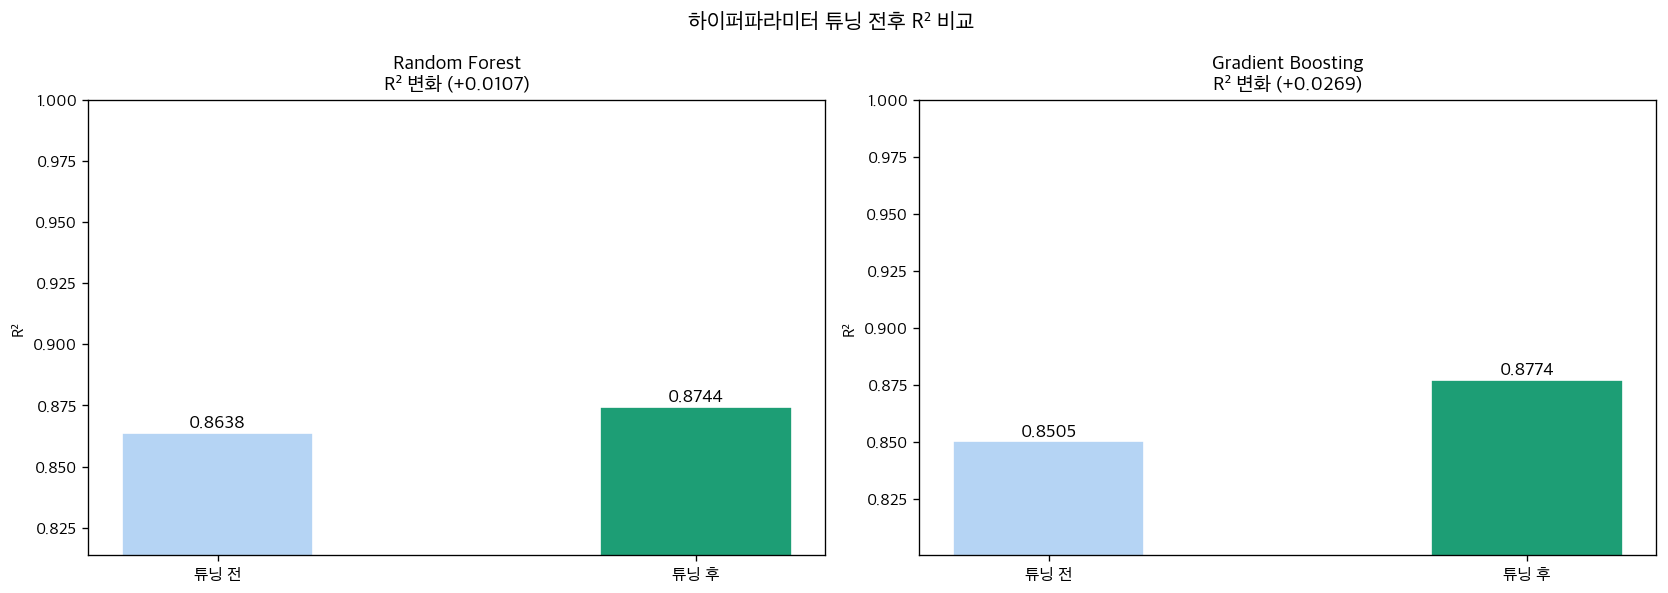

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, base, tuned, label in zip(
    axes,
    ['RandomForest', 'GradientBoosting'],
    ['RF_tuned',     'GB_tuned'],
    ['Random Forest', 'Gradient Boosting']
):
    before = results_df.loc[base, 'R²']
    after  = tuning_results[tuned]['R²']
    bars = ax.bar(['튜닝 전', '튜닝 후'], [before, after],
                  color=['#B5D4F4', '#1D9E75'], edgecolor='white', width=0.4)
    for bar, val in zip(bars, [before, after]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(min(before, after) - 0.05, 1.0)
    ax.set_title(f'{label}\nR² 변화 (+{after-before:.4f})')
    ax.set_ylabel('R²')

plt.suptitle('하이퍼파라미터 튜닝 전후 R² 비교 ', fontsize=13)
plt.tight_layout()
plt.show()

위 셀은 시각화 자료로 사용, 이전 셀과 함께 한 시트로 만들기

In [27]:
import shap
shap.initjs()   # 주피터 환경에서 JS 초기화
print('SHAP 버전:', shap.__version__)

SHAP 버전: 0.51.0


 SHAP란?
Shapley Additive exPlanations의 약자
 
 핵심 목적은 머신러닝 모델이 왜 이런 예측을 했는가를 설명해주는 도구이다.

 각 변수 영향 방향과 각 변수 영향 크기, 개별 환자 예측 이유까지 설명이 가능하다.

In [28]:
# TreeExplainer: 트리 모델에 특화된 빠른 SHAP 계산
explainer = shap.TreeExplainer(best_tuned_model)
shap_values = explainer.shap_values(X_test_proc)

print(f'SHAP values shape: {shap_values.shape}')
print('계산 완료 — 아래 시각화를 확인하세요')

SHAP values shape: (268, 13)
계산 완료 — 아래 시각화를 확인하세요


다음으로는 SHAP 기반 Explainable AI 분석을 수행하기 위해 SHAP 값을 계산하였습니다.

이번 분석에서는 최종 튜닝 모델에 대해 TreeExplainer를 사용하였으며, 테스트 데이터 전체에 대해 SHAP 값을 계산하였습니다.

출력 결과인 (268, 13)은:

* 268개의 테스트 샘플 각각에 대해
* 13개의 feature 영향도를 계산했다는 의미입니다.

이를 통해 이후 단계에서:

* 어떤 변수가 전체적으로 중요한지
* 변수들이 의료비를 증가시키는 방향인지 감소시키는 방향인지
* 특정 환자의 예측이 왜 높게 나왔는지

등을 보다 상세하게 해석할 수 있게 됩니다.

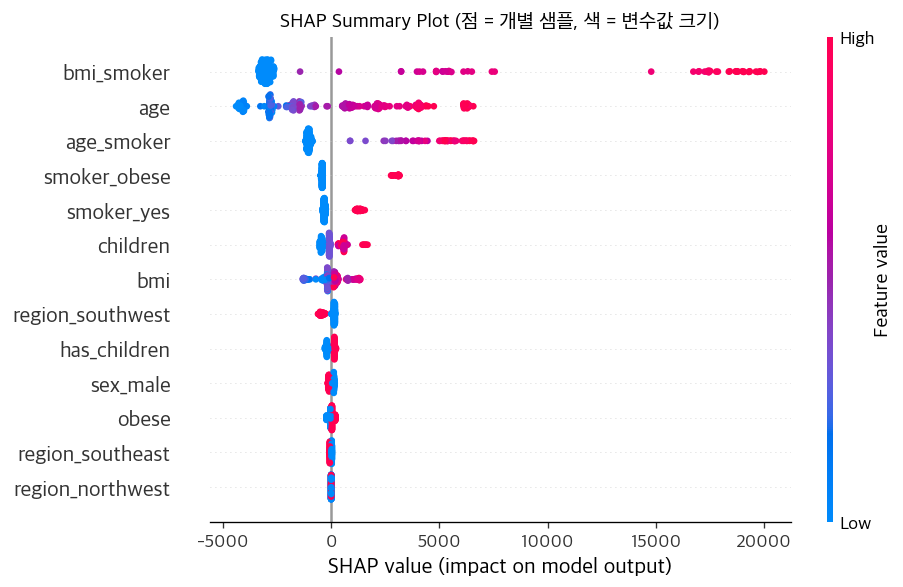

In [50]:
# 컬럼명 복원 (전처리 파이프라인에서)
ohe_cols = preprocessor.named_transformers_['cat']\
           .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_cols

# Summary Plot: 전체 변수 중요도 + 방향성
shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names=all_feature_names,
    plot_type='dot',
    max_display=15,
    show=False
)

# SHAP가 생성한 현재 figure 크기 조정
plt.gcf().set_size_inches(8, 5)

plt.title('SHAP Summary Plot (점 = 개별 샘플, 색 = 변수값 크기)')
plt.tight_layout()
plt.show()

다음으로는 SHAP Summary Plot을 통해 변수들이 의료비 예측에 어떤 방향과 크기로 영향을 주는지 분석하였습니다.

SHAP Summary Plot은:

* 변수 중요도,
* 영향 방향,
* 그리고 변수값 크기에 따른 효과를 동시에 보여주는 Explainable AI 시각화입니다.

y축은 변수 중요도 순서를 의미하며, 위에 위치할수록 모델 예측에 중요한 변수입니다.

x축의 SHAP value는 해당 변수가 의료비 예측값을 증가시키는지 또는 감소시키는지를 의미합니다.

또한 색상은 변수값 크기를 나타내며, 빨간색은 높은 값, 파란색은 낮은 값을 의미합니다.

분석 결과 가장 중요한 변수는 bmi_smoker로 나타났습니다.

특히 높은 bmi_smoker 값을 가진 샘플들이 오른쪽에 강하게 분포하고 있었는데, 이는 흡연 상태에서 BMI가 증가할수록 의료비를 크게 증가시키는 방향으로 작용한다는 것을 의미합니다.

또한 age 변수 역시 높은 값일수록 의료비 증가 방향으로 작용하였으며, age_smoker 변수 역시 유사한 패턴을 보였습니다.

이는 단순히 나이가 많거나 흡연을 하는 것 자체보다, 고령과 흡연이 결합될 때 의료비 위험이 더욱 커질 수 있다는 점을 보여줍니다.

반면 성별이나 지역 변수들은 대부분 SHAP 값이 0 근처에 분포하였으며, 상대적으로 의료비 예측에 미치는 영향이 작게 나타났습니다.

종합적으로 SHAP 분석 결과, 의료비는 단일 요인보다는 흡연, BMI, 연령과 같은 위험요인들이 결합될 때 크게 증가하는 패턴을 보였으며, 앞서 수행한 Feature Engineering의 효과 역시 함께 검증할 수 있었습니다.


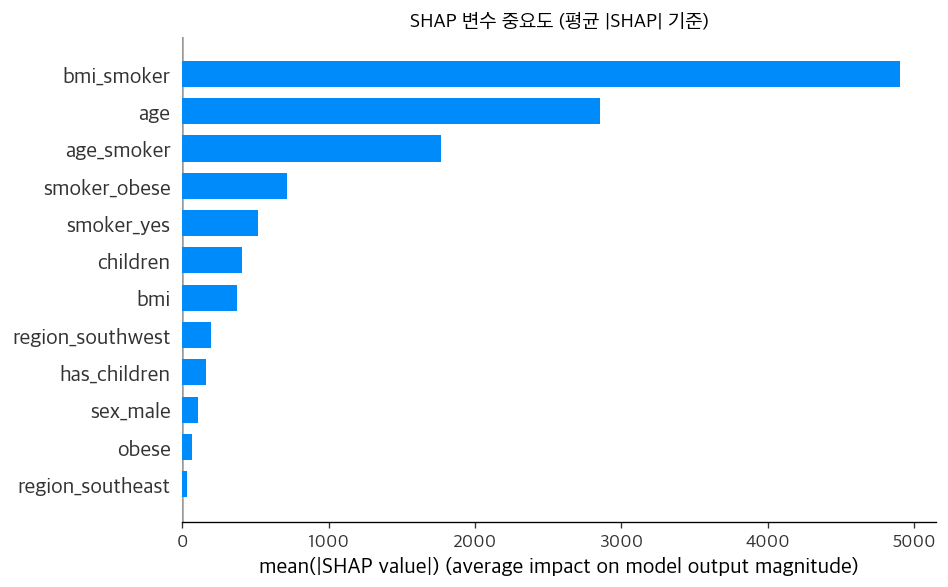

In [51]:
# Bar Plot: 평균 절댓값 기준 변수 중요도
shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=12,
    show=False
)

# figure 크기 조절
plt.gcf().set_size_inches(8, 5)

plt.title('SHAP 변수 중요도 (평균 |SHAP| 기준)')
plt.tight_layout()
plt.show()

다음 그래프는 SHAP 값을 기반으로 변수 중요도를 평균 절댓값 기준으로 정리한 결과입니다.
즉, 각 변수가 의료비 예측에 평균적으로 얼마나 큰 영향을 미쳤는지를 나타냅니다.


이전 시각화 자료와 한 시트로 만들어서 발표할 것

샘플 #0 실제 의료비: $9,095
샘플 #0 예측 의료비: $10,563


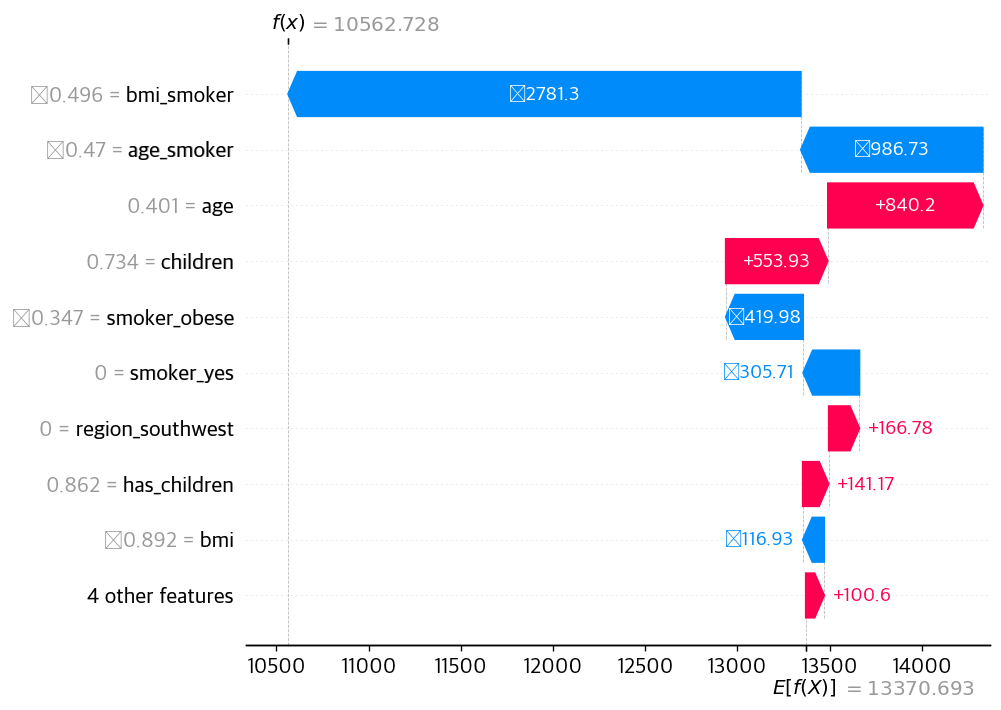

<Figure size 768x576 with 0 Axes>

In [31]:
# Waterfall Plot: 특정 환자 1명의 예측값 분해
sample_idx = 0   # 분석할 테스트 샘플 인덱스 (변경 가능)

print(f'샘플 #{sample_idx} 실제 의료비: ${y_test.iloc[sample_idx]:,.0f}')
print(f'샘플 #{sample_idx} 예측 의료비: ${best_tuned_model.predict(X_test_proc[[sample_idx]])[0]:,.0f}')

sample_idx = 0

shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value[0],
    data=X_test_proc[sample_idx],
    feature_names=all_feature_names
)

shap.plots.waterfall(shap_exp)

plt.tight_layout()
plt.show()

다음으로는 SHAP Waterfall Plot을 사용하여 특정 환자 1명에 대한 예측 결과를 개별적으로 해석하였습니다.

Waterfall Plot은 평균적인 예측값에서 시작하여 각 변수들이 예측값을 얼마나 증가시키거나 감소시켰는지를 단계적으로 보여주는 시각화입니다.

현재 샘플의 실제 의료비는 약 9,095달러였으며, 모델은 약 10,563달러로 예측하였습니다.

그래프 하단의 기준값인 약 13,370달러는 전체 평균적인 예측 의료비를 의미합니다.

이후 각 변수들이 예측값을 증가시키거나 감소시키면서 최종 예측값으로 이동하게 됩니다.

분석 결과 가장 큰 영향을 준 변수는 bmi_smoker 변수였습니다.

해당 변수는 약 -2,781 수준으로 의료비를 감소시키는 방향으로 작용하였는데, 이는 이 환자가 흡연과 BMI 결합 위험도가 낮은 특성을 가지고 있었기 때문으로 해석할 수 있습니다.

또한 age_smoker 변수 역시 의료비 감소 방향으로 작용하였으며, 이는 고령 흡연 위험 패턴이 크지 않았음을 의미합니다.

반면 age 변수는 의료비를 증가시키는 방향으로 작용하였으며, 나이 증가가 의료비 상승 요인으로 반영된 것을 확인할 수 있었습니다.

종합적으로 이 환자는 연령 요인은 일부 존재했지만, 흡연 관련 위험도가 낮았기 때문에 평균적인 환자보다 낮은 의료비 수준으로 예측된 사례라고 해석할 수 있습니다.

이를 통해 SHAP 분석은 단순히 모델 성능을 평가하는 수준을 넘어, 개별 환자의 예측 결과가 왜 그렇게 도출되었는지까지 설명 가능하다는 점을 확인할 수 있었습니다.


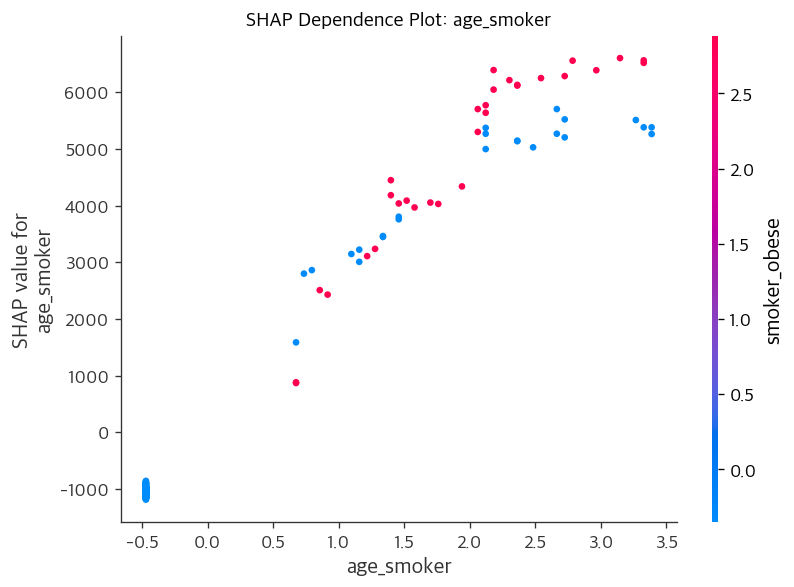

In [52]:
# Dependence Plot: 핵심 변수(age_smoker)의 SHAP 값 분포
top_feature = 'age_smoker'
top_idx = all_feature_names.index(top_feature)

fig, ax = plt.subplots(figsize=(7, 5))

shap.dependence_plot(
    top_idx,
    shap_values,
    X_test_proc,
    feature_names=all_feature_names,
    interaction_index=all_feature_names.index('smoker_obese')
        if 'smoker_obese' in all_feature_names else 'auto',
    ax=ax,
    show=False
)

ax.set_title(f'SHAP Dependence Plot: {top_feature}')

plt.tight_layout()
plt.show()

다음으로는 SHAP Dependence Plot을 통해 age_smoker 변수의 영향 패턴을 보다 상세하게 분석하였습니다.

x축은 age_smoker 변수값을 의미하며, 이는 연령과 흡연 효과가 결합된 변수입니다.

y축의 SHAP 값은 해당 변수가 의료비 예측에 얼마나 영향을 미쳤는지를 나타냅니다.

그래프를 보면 age_smoker 값이 증가할수록 SHAP 값 역시 크게 증가하는 패턴을 확인할 수 있습니다.

즉, 고령 흡연자일수록 의료비 예측값이 크게 증가하는 방향으로 작용하였음을 의미합니다.

또한 점의 색상은 smoker_obese 변수값을 나타내는데, 비만과 흡연 위험이 함께 존재하는 경우 더 높은 SHAP 값이 나타나는 경향을 확인할 수 있었습니다.

이는 단순히 나이 또는 흡연 자체만의 영향이 아니라, 여러 위험요인이 결합될 때 의료비 증가 효과가 더욱 커질 수 있다는 점을 보여줍니다.

특히 이러한 결과는 앞서 수행한 Feature Engineering과 SHAP Summary 분석 결과와도 일관된 패턴을 보였으며, 의료비 데이터에서 변수 간 상호작용이 매우 중요한 역할을 한다는 점을 확인할 수 있었습니다.


In [33]:
print('=' * 65)
print('최종 분석 결과 요약 (튜닝 + SHAP 포함)')
print('=' * 65)

print('\n[모델 성능 비교 (전체)]')
print(comparison_df.sort_values('R²', ascending=False).round(4).to_string())

print(f'\n[최우수 모델] {best_tuned_name}')
r2_val = tuning_results[best_tuned_name]["R²"]
rmse_val = tuning_results[best_tuned_name]["RMSE"]
mae_val = tuning_results[best_tuned_name]["MAE"]
mape_val = tuning_results[best_tuned_name]["MAPE(%)"]
print(f'  R²   : {r2_val:.4f}  → 의료비 분산의 {r2_val*100:.1f}% 설명')
print(f'  RMSE : ${rmse_val:>,.0f}')
print(f'  MAE  : ${mae_val:>,.0f}')
print(f'  MAPE : {mape_val:.1f}%')

print('\n[SHAP 분석 인사이트]')
shap_mean = pd.DataFrame({
    '변수': all_feature_names,
    '평균 |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('평균 |SHAP|', ascending=False)

print('Top 5 핵심 변수:')
print(shap_mean.head(5).to_string(index=False))

print('\n[결론]')
print('  - 흡연 여부와 흡연×나이 상호작용 변수가 의료비에 가장 큰 영향')
print('  - 비만(BMI≥30)과 흡연의 복합 효과도 유의미한 비용 증가 요인')
print('  - SHAP waterfall로 개별 환자 의료비 원인 설명 가능')

최종 분석 결과 요약 (튜닝 + SHAP 포함)

[모델 성능 비교 (전체)]
                      R²        RMSE        MAE   MAPE(%)
GB_tuned          0.8774   4362.1834  2507.5390   34.1215
RF_tuned          0.8744   4415.1970  2540.7523   33.6857
RandomForest      0.8638   4598.8378  2557.1412   32.1415
LinearRegression  0.8586   4685.2792  2356.1102   17.7914
GradientBoosting  0.8505   4817.8956  2683.3720   30.2320
Ridge             0.7933   5665.1380  2633.4604   19.6432
Lasso            -0.0976  13053.7193  8603.1573  107.4969

[최우수 모델] GB_tuned
  R²   : 0.8774  → 의료비 분산의 87.7% 설명
  RMSE : $4,362
  MAE  : $2,508
  MAPE : 34.1%

[SHAP 분석 인사이트]
Top 5 핵심 변수:
          변수   평균 |SHAP|
  bmi_smoker 4905.377059
         age 2851.492889
  age_smoker 1770.441146
smoker_obese  715.877264
  smoker_yes  515.254745

[결론]
  - 흡연 여부와 흡연×나이 상호작용 변수가 의료비에 가장 큰 영향
  - 비만(BMI≥30)과 흡연의 복합 효과도 유의미한 비용 증가 요인
  - SHAP waterfall로 개별 환자 의료비 원인 설명 가능


마지막으로 SHAP 기반 분석 결과를 종합적으로 정리하였습니다.

SHAP 분석 결과 가장 중요한 변수는 bmi_smoker 변수로 나타났습니다.

이는 단순 BMI 자체보다, 흡연 상태에서 BMI가 증가하는 경우 의료비가 훨씬 크게 증가할 수 있음을 의미합니다.

또한 age_smoker 변수 역시 높은 중요도를 보였는데, 이를 통해 고령과 흡연이 결합될 경우 의료비 증가 효과가 더욱 커지는 패턴을 확인할 수 있었습니다.

반면 성별이나 지역 변수는 상대적으로 영향력이 낮게 나타났으며, 의료비는 단일 요인보다는 여러 위험요인의 상호작용에 의해 크게 영향을 받는다는 점을 확인할 수 있었습니다.

또한 SHAP Waterfall 분석을 통해 개별 환자의 의료비 예측 원인까지 설명 가능하다는 점도 확인할 수 있었습니다.

즉 본 프로젝트에서는 단순히 예측 성능이 높은 모델을 만드는 것에 그치지 않고, 의료비 증가 원인을 해석 가능한 형태로 분석했다는 점에서 의미가 있다고 판단하였습니다.


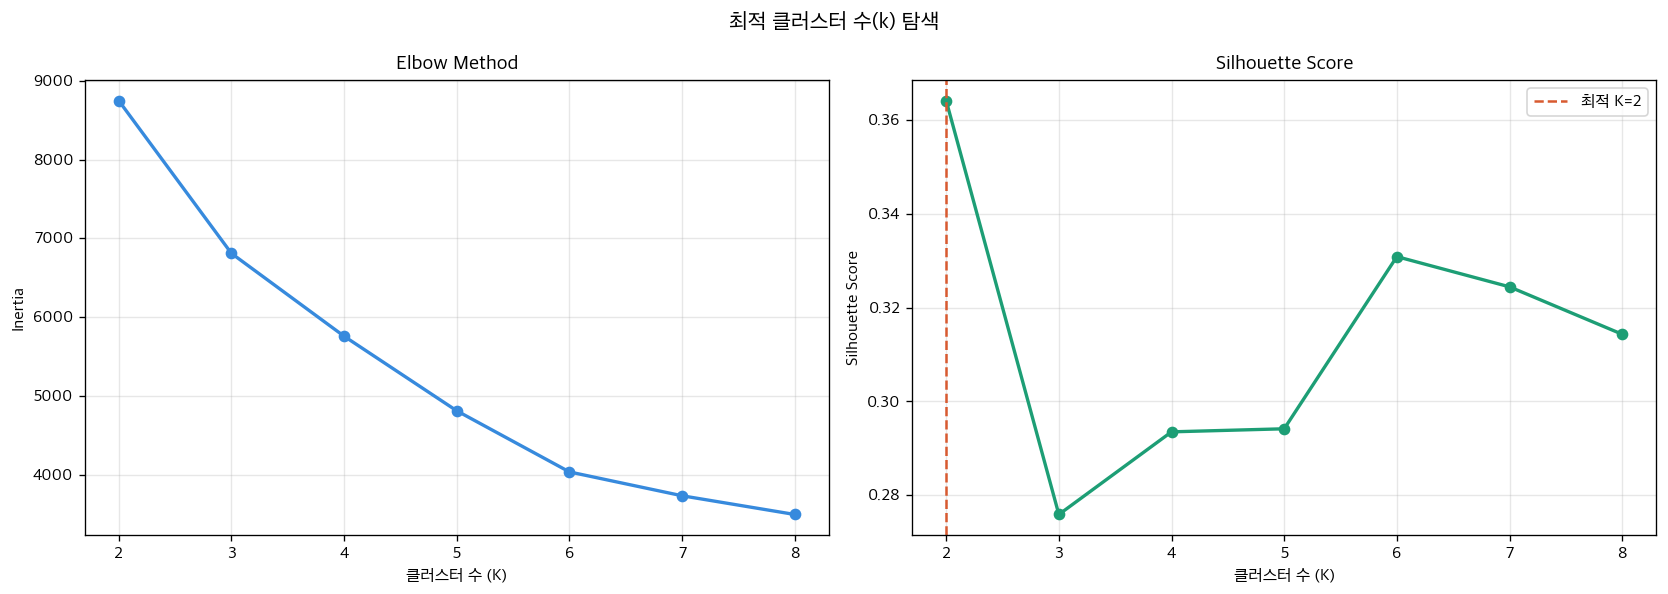

Elbow 기준 추천 K: 그래프에서 꺾이는 지점 확인
Silhouette 기준 최적 K: 2  (score=0.3641)


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 전체 데이터로 클러스터링
X_all_proc = preprocessor.transform(df_feat[feature_cols])

# 최적 K 탐색: Elbow Method + Silhouette Score
k_range = range(2, 9)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_all_proc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_all_proc, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inertias, marker='o', color='#378ADD', linewidth=2)
axes[0].set_xlabel('클러스터 수 (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(k_range, sil_scores, marker='o', color='#1D9E75', linewidth=2)
best_k = k_range.start + sil_scores.index(max(sil_scores))
axes[1].axvline(best_k, color='#D85A30', linestyle='--', label=f'최적 K={best_k}')
axes[1].set_xlabel('클러스터 수 (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('최적 클러스터 수(k) 탐색', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Elbow 기준 추천 K: 그래프에서 꺾이는 지점 확인')
print(f'Silhouette 기준 최적 K: {best_k}  (score={max(sil_scores):.4f})')

본 분석에서는 전처리된 전체 데이터를 기반으로 K-Means 알고리즘을 적용하였으며, 적절한 클러스터 개수를 결정하기 위해 Elbow Method와 Silhouette Score를 함께 사용하였습니다.

먼저 왼쪽 Elbow 그래프는 클러스터 수가 증가할수록 군집 내부 오차가 어떻게 감소하는지를 보여줍니다.

일반적으로 그래프가 급격히 꺾이는 지점을 적절한 K로 판단하는데, 본 결과에서는 K가 증가할수록 감소 폭이 점차 완만해지는 모습을 확인할 수 있었습니다.

다음으로 오른쪽 Silhouette Score(실루엣 스코어) 그래프는 군집 간 분리도와 응집도를 동시에 평가하는 지표입니다.

값이 클수록 군집이 서로 잘 구분되면서 내부적으로도 유사한 특성을 가진다는 의미입니다.

분석 결과 K=2에서 가장 높은 Silhouette Score를 보였으며, 이를 통해 전체 환자 데이터가 크게 두 개의 주요 그룹으로 구분될 가능성이 높다고 판단하였습니다.

따라서 이후 분석에서는 K=2를 기준으로 환자 군집을 나누고, 각 군집의 의료비 및 위험 특성을 비교 분석하였습니다.

In [35]:
BEST_K = best_k   # 필요시 수동 변경 가능 (예: BEST_K = 3)

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_all_proc)

df_cluster = df_feat.copy()
df_cluster['cluster'] = cluster_labels

cluster_summary = df_cluster.groupby('cluster').agg(
    인원수=('charges', 'count'),
    평균_의료비=('charges', 'mean'),
    중앙값_의료비=('charges', 'median'),
    평균_나이=('age', 'mean'),
    평균_BMI=('bmi', 'mean'),
    흡연율=('smoker_bin', 'mean'),
    비만율=('obese', 'mean'),
).round(2)

cluster_summary = cluster_summary.sort_values('평균_의료비', ascending=False)
risk_labels = ['고위험군', '중위험군', '저위험군', '최저위험군'][:BEST_K]
cluster_summary['위험등급'] = risk_labels

rank_map = dict(zip(cluster_summary.index, risk_labels))
df_cluster['위험등급'] = df_cluster['cluster'].map(rank_map)

print('=== 클러스터별 특성 요약 ===')
print(cluster_summary.to_string())

=== 클러스터별 특성 요약 ===
          인원수    평균_의료비   중앙값_의료비  평균_나이  평균_BMI  흡연율   비만율  위험등급
cluster                                                          
1         270  32322.44  34644.99  38.81   30.86  1.0  0.54  고위험군
0        1068   8453.90   7353.16  39.31   30.61  0.0  0.53  중위험군


최종적으로 선택된 K=2 기준으로 환자 데이터를 군집화한 뒤, 각 클러스터의 특성을 비교 분석하였습니다.

분석 결과 전체 환자는 크게 두 개의 그룹으로 구분되었습니다.

첫 번째 클러스터는 평균 의료비가 약 32,000달러 수준으로 매우 높게 나타났으며, 흡연율이 100%에 가까운 특징을 보였습니다.

또한 BMI 평균 역시 높게 나타나 흡연과 비만 위험요인이 동시에 존재하는 고위험군 특성을 보였습니다.

반면 두 번째 클러스터는 평균 의료비가 약 8,400달러 수준으로 상대적으로 낮았으며, 흡연율이 거의 0에 가까운 특징을 보였습니다.

흥미로운 점은 두 그룹의 평균 나이와 BMI 자체는 큰 차이가 없었지만, 흡연 여부에 따라 의료비 수준이 극단적으로 달라졌다는 점입니다.

이는 앞선 SHAP 및 변수 중요도 분석 결과와도 일관된 결과로, 흡연이 의료비 증가의 핵심적인 분기 요인이라는 점을 다시 한번 확인할 수 있었습니다.

따라서 본 군집분석을 통해 단순 예측을 넘어, 실제 환자를 의료비 위험 수준에 따라 그룹화하고 고위험군을 식별할 수 있는 가능성을 확인하였습니다.

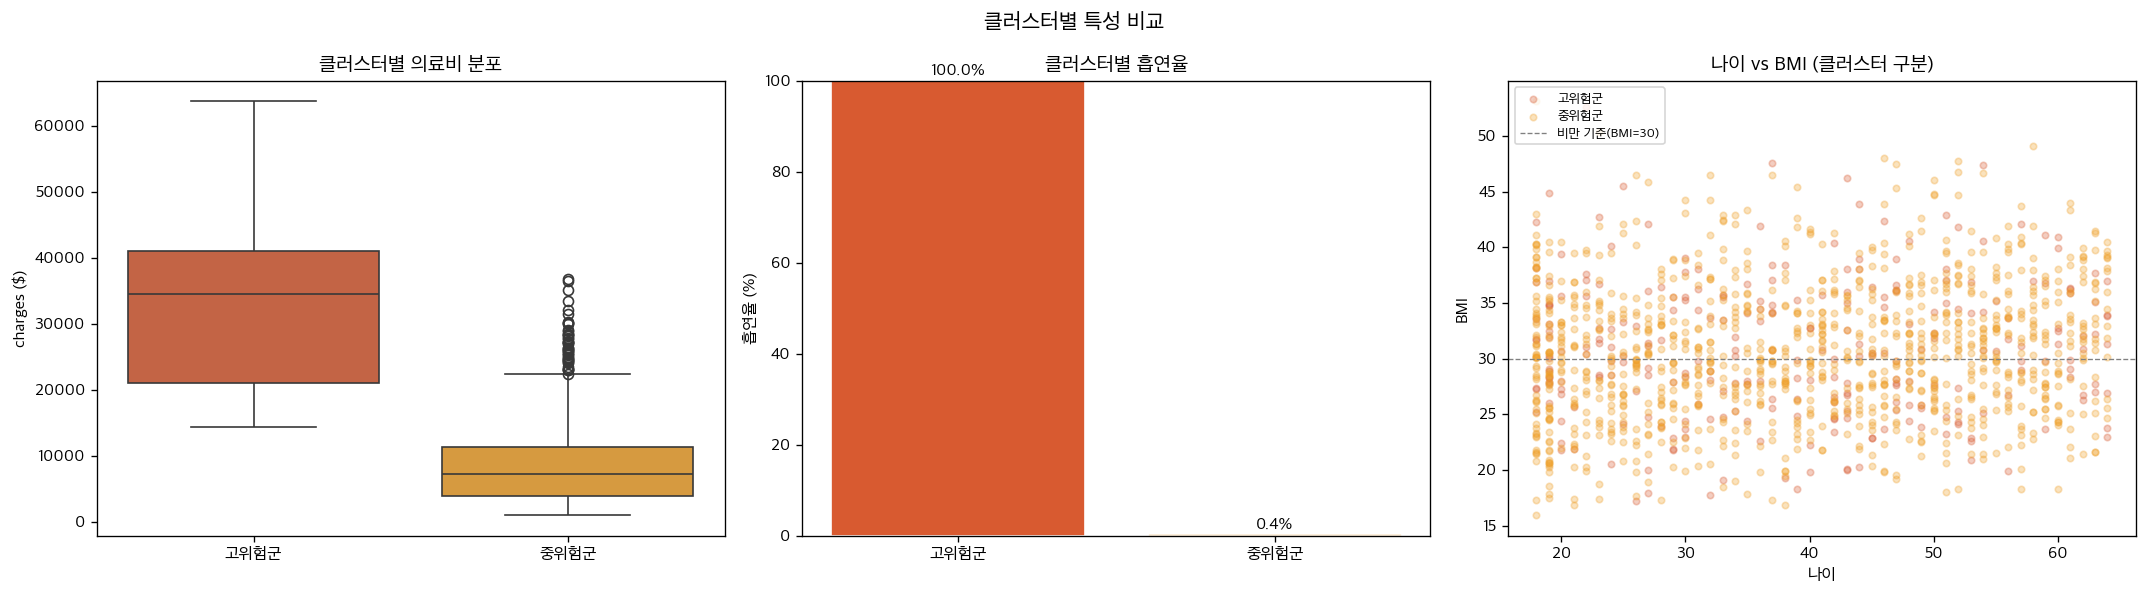

In [36]:
palette = {'고위험군': '#D85A30', '중위험군': '#EF9F27',
           '저위험군': '#378ADD', '최저위험군': '#1D9E75'}
order = [l for l in ['고위험군', '중위험군', '저위험군', '최저위험군'] if l in df_cluster['위험등급'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 박스플롯
sns.boxplot(x='위험등급', y='charges', data=df_cluster,
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('클러스터별 의료비 분포')
axes[0].set_xlabel('')
axes[0].set_ylabel('charges ($)')

# 흡연율 막대
smoker_rate = df_cluster.groupby('위험등급')['smoker_bin'].mean().reindex(order) * 100
bars = axes[1].bar(order, smoker_rate.values,
                   color=[palette[o] for o in order], edgecolor='white')
for bar, val in zip(bars, smoker_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('클러스터별 흡연율')
axes[1].set_ylabel('흡연율 (%)')
axes[1].set_ylim(0, 100)

# 나이 vs BMI 산점도
for grp in order:
    sub = df_cluster[df_cluster['위험등급'] == grp]
    axes[2].scatter(sub['age'], sub['bmi'],
                    alpha=0.3, s=15, color=palette[grp], label=grp)
axes[2].set_xlabel('나이')
axes[2].set_ylabel('BMI')
axes[2].axhline(30, color='gray', linestyle='--', linewidth=0.8, label='비만 기준(BMI=30)')
axes[2].set_title('나이 vs BMI (클러스터 구분)')
axes[2].legend(fontsize=8, loc='upper left')

plt.suptitle('클러스터별 특성 비교', fontsize=13)
plt.tight_layout()
plt.show()

다음으로는 군집별 특성을 보다 직관적으로 비교하기 위해 시각화를 수행하였습니다.

먼저 왼쪽 박스플롯은 각 클러스터의 의료비 분포를 나타냅니다.

분석 결과 고위험군은 중위험군에 비해 전체 의료비 수준이 매우 높게 나타났으며, 중앙값과 상위 의료비 범위 역시 크게 차이를 보였습니다.

특히 고위험군은 의료비 분포 자체가 전체적으로 위쪽으로 이동해 있었으며, 이는 단순 일부 이상치가 아니라 집단 전체가 높은 의료비 특성을 가진다는 것을 의미합니다.

가운데 그래프는 클러스터별 흡연율을 비교한 결과입니다.

고위험군의 흡연율은 거의 100% 수준으로 나타난 반면, 중위험군은 거의 흡연자가 존재하지 않는 수준이었습니다.

이는 앞선 머신러닝 모델과 SHAP 분석 결과에서 확인했던 것처럼, 흡연 여부가 의료비를 구분하는 가장 핵심적인 요인이라는 점을 다시 한번 보여주는 결과입니다.

오른쪽 그래프는 나이와 BMI 분포를 군집별로 시각화한 결과입니다.

고위험군은 BMI 30 이상의 비만 구간에 상대적으로 많이 분포하고 있었으며, 연령 증가와 함께 BMI가 높은 환자들이 집중되는 경향을 확인할 수 있었습니다.

즉 단순히 나이나 BMI 하나만의 문제가 아니라, 흡연과 비만, 연령 증가가 함께 결합될 때 의료비 위험도가 크게 상승하는 패턴을 확인할 수 있었습니다.

종합적으로 군집분석 결과는 앞서 수행한 머신러닝 및 SHAP 분석 결과와 일관된 방향을 보였으며, 실제 환자를 위험 수준에 따라 구분할 수 있는 가능성을 보여주었다는 점에서 의미가 있다고 생각합니다.


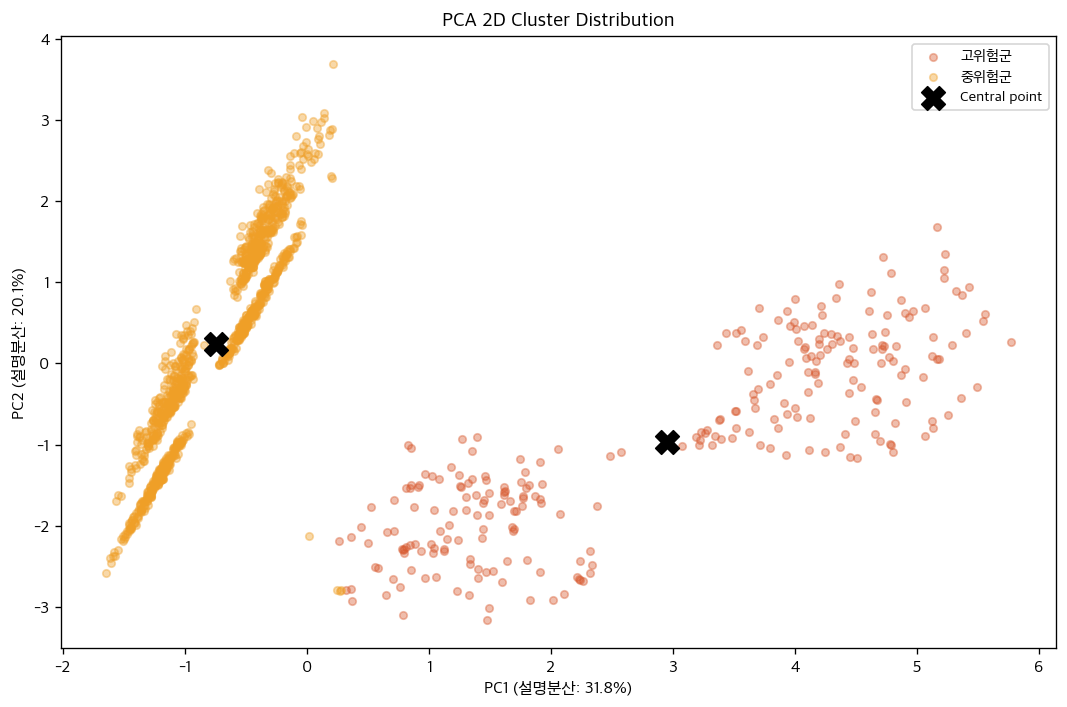

PC1+PC2 누적 설명분산: 51.9%


In [37]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_proc)

plt.figure(figsize=(9, 6))
for grp in order:
    mask = df_cluster['위험등급'] == grp
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                alpha=0.4, s=20, color=palette[grp], label=grp)

centers_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            marker='X', s=200, c='black', zorder=5, label='Central point')

plt.xlabel(f'PC1 (설명분산: {pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 (설명분산: {pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D Cluster Distribution')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'PC1+PC2 누적 설명분산: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

마지막으로 PCA를 활용하여 군집 결과를 2차원 공간에서 시각화하였습니다.

본 분석에서는 전처리된 다차원 데이터를 2개의 주성분(PC1, PC2)으로 축소하여 클러스터 분포를 시각적으로 확인하였습니다.

분석 결과 PC1과 PC2만으로 전체 데이터 분산의 약 51.9%를 설명할 수 있었으며, 이를 통해 주요 패턴을 비교적 잘 표현할 수 있었습니다.

그래프를 보면 고위험군과 중위험군이 비교적 뚜렷하게 분리되어 있는 모습을 확인할 수 있습니다.

특히 고위험군은 PCA 공간에서 하나의 독립적인 영역에 밀집되어 나타났으며, 이는 해당 그룹이 다른 환자군과 구별되는 특성을 가진다는 것을 의미합니다.

반면 중위험군은 상대적으로 넓게 퍼져 있었는데, 이는 의료비 특성이 비교적 다양하게 분포하고 있음을 의미합니다.

또한 검은색 X 표시는 각 클러스터의 중심점(centroid)을 나타내며, 두 그룹 간 중심 위치 역시 상당히 떨어져 있는 모습을 확인할 수 있었습니다.

즉 본 결과는 앞서 수행한 K-Means 군집분석이 단순 수치상의 분리가 아니라 실제 데이터 구조에서도 의미 있는 차이를 가진다는 점을 시각적으로 보여주는 결과라고 할 수 있습니다.

종합적으로 PCA 시각화를 통해 의료비 데이터 내에 고위험 환자군이 비교적 명확하게 존재한다는 점을 확인할 수 있었으며, 이는 향후 환자 위험군 분류 및 예방 중심 의료 관리에 활용될 가능성을 보여주었습니다.

In [38]:
print('=' * 65)
print('Part 4. 클러스터링 분석 요약')
print('=' * 65)

for grp in order:
    sub = df_cluster[df_cluster['위험등급'] == grp]
    print(f"\n[{grp}] ({len(sub)}명, {len(sub)/len(df_cluster)*100:.1f}%)")
    print(f"  평균 의료비: ${sub['charges'].mean():>10,.0f}")
    print(f"  평균 나이:   {sub['age'].mean():>6.1f}세")
    print(f"  평균 BMI:    {sub['bmi'].mean():>6.1f}")
    print(f"  흡연율:      {sub['smoker_bin'].mean()*100:>6.1f}%")
    print(f"  비만율:      {sub['obese'].mean()*100:>6.1f}%")

Part 4. 클러스터링 분석 요약

[고위험군] (270명, 20.2%)
  평균 의료비: $    32,322
  평균 나이:     38.8세
  평균 BMI:      30.9
  흡연율:       100.0%
  비만율:        53.7%

[중위험군] (1068명, 79.8%)
  평균 의료비: $     8,454
  평균 나이:     39.3세
  평균 BMI:      30.6
  흡연율:         0.4%
  비만율:        52.6%


분석 결과 전체 환자는 크게 고위험군과 중위험군 두 그룹으로 구분되었습니다.

고위험군은 전체의 약 20% 정도를 차지하였으며, 평균 의료비는 약 32,000달러 수준으로 매우 높게 나타났습니다.

특히 흡연율이 100%로 나타났으며, 평균 BMI 역시 비만 기준인 30 이상 수준을 보였습니다.

반면 중위험군은 전체의 약 80%를 차지하였으며, 평균 의료비는 약 8,400달러 수준으로 상대적으로 낮게 나타났습니다.

흥미로운 점은 두 그룹의 평균 나이와 BMI 자체는 큰 차이가 없었지만, 흡연율에서는 매우 큰 차이를 보였다는 점입니다.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)

# 고비용 환자 정의: 의료비 상위 25% (75th percentile 이상)
threshold = df_feat['charges'].quantile(0.75)
print(f'고비용 기준 (75th percentile): ${threshold:,.0f}')

y_cls = (df_feat['charges'] >= threshold).astype(int)
print(f'고비용 환자: {y_cls.sum()}명 ({y_cls.mean()*100:.1f}%)')
print(f'일반 환자:   {(1-y_cls).sum()}명 ({(1-y_cls).mean()*100:.1f}%)')

X_tr_cls, X_te_cls, y_tr_cls, y_te_cls = train_test_split(
    X_all_proc, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print(f'\nTrain: {X_tr_cls.shape}  |  Test: {X_te_cls.shape}')
print(f'Train 고비용 비율: {y_tr_cls.mean()*100:.1f}%')
print(f'Test  고비용 비율: {y_te_cls.mean()*100:.1f}%')

고비용 기준 (75th percentile): $16,640
고비용 환자: 335명 (25.0%)
일반 환자:   1003명 (75.0%)

Train: (1070, 13)  |  Test: (268, 13)
Train 고비용 비율: 25.0%
Test  고비용 비율: 25.0%


이후에는 단순 의료비 예측을 넘어, 실제로 의료비가 매우 높아질 가능성이 있는 환자를 사전에 분류하기 위한 고비용 환자 분류(Classification) 분석을 수행하였습니다.

먼저 의료비 상위 25% 구간을 기준으로 고비용 환자를 정의하였습니다.

분석 결과 기준 의료비는 약 16,640달러로 나타났으며, 전체 환자 중 약 25%가 고비용 환자로 분류되었습니다.

이후 분류 모델 학습을 위해 target 변수를 이진 형태로 변환하였습니다.

즉 의료비가 기준 이상이면 1, 그렇지 않으면 0으로 설정하여 고비용 환자 여부를 예측하는 classification 문제로 변환하였습니다.

그 다음 train_test_split을 사용하여 데이터를 학습용과 테스트용으로 분리하였으며, stratify 옵션을 적용하여 Train과 Test 데이터 모두 동일한 고비용 환자 비율을 유지하도록 하였습니다.

실제 결과에서도 Train과 Test 모두 약 25% 수준의 고비용 비율을 유지하는 것을 확인할 수 있었습니다.

In [40]:
cls_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=200,
                                                      learning_rate=0.1,
                                                      max_depth=4,
                                                      random_state=42),
}

cls_results = {}
for name, model in cls_models.items():
    model.fit(X_tr_cls, y_tr_cls)
    y_pred = model.predict(X_te_cls)
    y_prob = model.predict_proba(X_te_cls)[:, 1]
    auc    = roc_auc_score(y_te_cls, y_prob)
    ap     = average_precision_score(y_te_cls, y_prob)
    report = classification_report(y_te_cls, y_pred, output_dict=True)
    cls_results[name] = {
        'ROC-AUC':  auc,
        'AP':       ap,
        'Precision': report['1']['precision'],
        'Recall':    report['1']['recall'],
        'F1':        report['1']['f1-score'],
        'model':     model,
        'y_prob':    y_prob,
        'y_pred':    y_pred,
    }
    print(f"{name:<22} AUC={auc:.4f}  AP={ap:.4f}  "
          f"Precision={report['1']['precision']:.3f}  "
          f"Recall={report['1']['recall']:.3f}  "
          f"F1={report['1']['f1-score']:.3f}")

best_cls_name = max(cls_results, key=lambda k: cls_results[k]['ROC-AUC'])
best_cls = cls_results[best_cls_name]
print(f'\n→ 최우수 분류 모델: {best_cls_name}  AUC={best_cls["ROC-AUC"]:.4f}')

LogisticRegression     AUC=0.8473  AP=0.8249  Precision=0.959  Recall=0.701  F1=0.810
RandomForest           AUC=0.8361  AP=0.8211  Precision=0.959  Recall=0.701  F1=0.810
GradientBoosting       AUC=0.8551  AP=0.8290  Precision=0.855  Recall=0.701  F1=0.770

→ 최우수 분류 모델: GradientBoosting  AUC=0.8551


다음으로는 고비용 환자 분류 모델 성능을 비교하였습니다.

이번 단계에서는 Logistic Regression, Random Forest, Gradient Boosting 총 3개의 분류 모델을 사용하였으며, 단순 정확도 대신 ROC-AUC, Precision, Recall, F1-score와 같은 다양한 분류 성능 지표를 함께 평가하였습니다.

먼저 ROC-AUC는 모델이 고비용 환자와 일반 환자를 얼마나 잘 구분하는지를 나타내는 지표입니다.

분석 결과 Gradient Boosting이 가장 높은 AUC 값인 약 0.855를 기록하며 가장 우수한 분류 성능을 보였습니다.

또한 Average Precision(AP) 역시 가장 높게 나타나 고비용 환자를 안정적으로 탐지하는 성능이 우수함을 확인할 수 있었습니다.

한편 Logistic Regression 역시 예상보다 높은 성능을 보였는데, 이는 앞서 수행한 로그 변환과 interaction 기반 Feature Engineering의 효과 때문으로 해석할 수 있습니다.

Precision과 Recall을 함께 보면, 모델들은 비교적 높은 Precision을 유지하면서도 약 70% 수준의 Recall을 보였습니다.

이는 모델이 고비용 환자를 예측했을 때 실제 고비용 환자일 확률이 높으며, 동시에 전체 고비용 환자의 상당 부분도 탐지하고 있음을 의미합니다.

특히 의료 분야에서는 단순 정확도보다 고위험 환자를 얼마나 잘 탐지하는지가 중요하기 때문에, Recall과 AUC를 함께 고려하는 것이 중요합니다.

종합적으로 이번 분류 분석에서는 단순 의료비 예측을 넘어, 실제로 의료비 위험이 높은 환자를 조기에 탐지할 수 있는 가능성을 확인하였으며, Gradient Boosting 기반 분류 모델이 가장 우수한 성능을 보이는 것을 확인할 수 있었습니다.


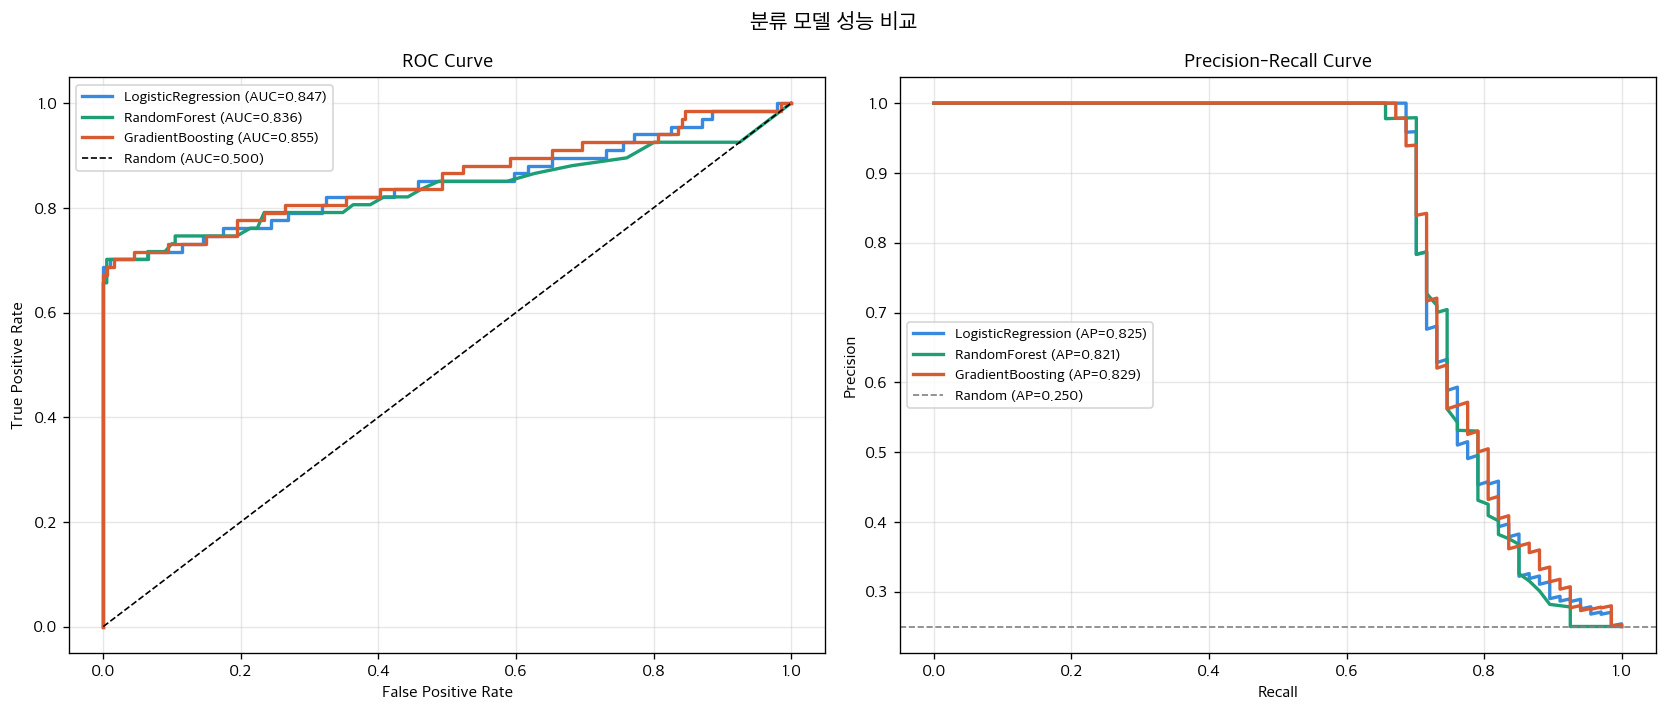

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_cls = ['#378ADD', '#1D9E75', '#D85A30']

for (name, res), color in zip(cls_results.items(), colors_cls):
    fpr, tpr, _ = roc_curve(y_te_cls, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={res['ROC-AUC']:.3f})")

    prec, rec, _ = precision_recall_curve(y_te_cls, res['y_prob'])
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f"{name} (AP={res['AP']:.3f})")

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

baseline = y_te_cls.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Random (AP={baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('분류 모델 성능 비교', fontsize=13)
plt.tight_layout()
plt.show()

다음으로는 분류 모델의 성능을 ROC Curve와 Precision-Recall Curve를 통해 시각적으로 비교하였습니다.

먼저 왼쪽의 ROC Curve는 모델이 고비용 환자와 일반 환자를 얼마나 잘 구분하는지를 나타내는 그래프입니다.

대각선 점선은 랜덤 분류 수준을 의미하며, 곡선이 왼쪽 위에 가까울수록 성능이 우수하다고 해석합니다.

분석 결과 세 모델 모두 랜덤 기준선을 크게 상회하는 성능을 보였으며, 특히 Gradient Boosting이 가장 높은 AUC 값인 약 0.855를 기록하였습니다.

이는 다양한 threshold 환경에서도 고비용 환자를 안정적으로 구분할 수 있음을 의미합니다.

오른쪽의 Precision-Recall Curve는 특히 클래스 불균형 상황에서 중요한 평가 지표입니다.

이번 데이터에서는 고비용 환자가 전체의 약 25% 수준이기 때문에 단순 정확도보다 Precision과 Recall의 균형이 더 중요합니다.

그래프를 보면 세 모델 모두 높은 Recall 구간까지 비교적 안정적인 Precision을 유지하는 모습을 보였습니다.

특히 Gradient Boosting은 AP 값 역시 가장 높게 나타나 고비용 환자를 탐지하는 과정에서 가장 안정적인 성능을 보였습니다.

종합적으로 ROC Curve와 Precision-Recall Curve 모두에서 Gradient Boosting 분류 모델이 가장 우수한 성능을 보였으며, 의료비 위험 환자 탐지 문제에서도 효과적으로 활용 가능함을 확인할 수 있었습니다.


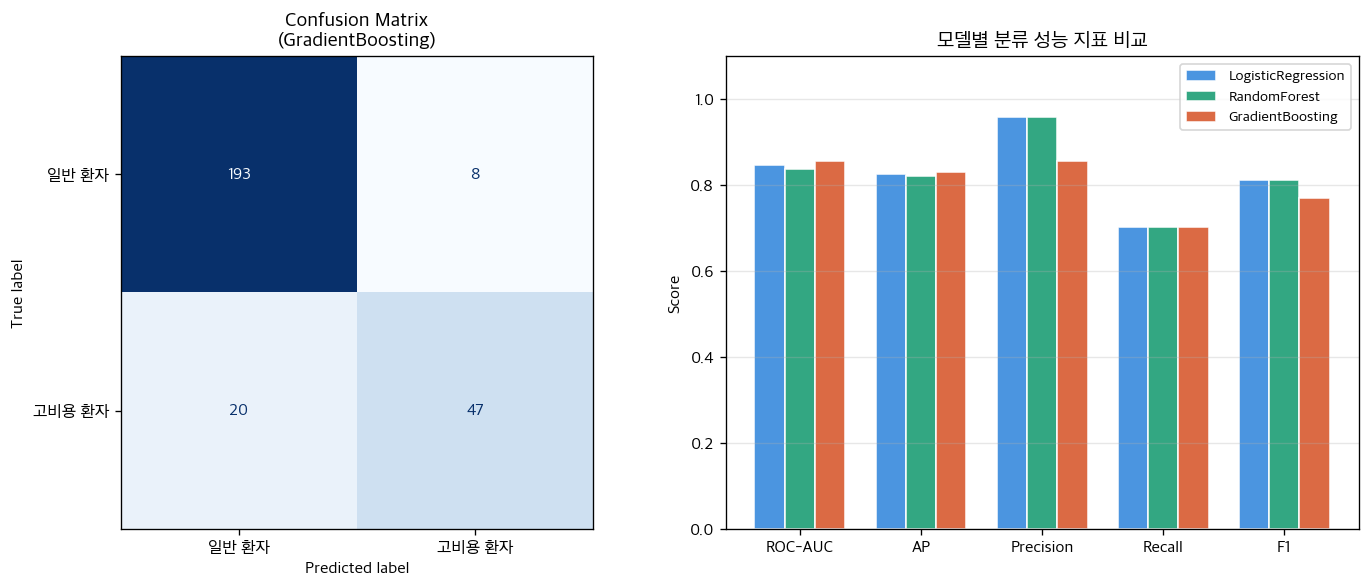


[GradientBoosting] 상세 분류 리포트
              precision    recall  f1-score   support

       일반 환자       0.91      0.96      0.93       201
      고비용 환자       0.85      0.70      0.77        67

    accuracy                           0.90       268
   macro avg       0.88      0.83      0.85       268
weighted avg       0.89      0.90      0.89       268



In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_te_cls, best_cls['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['일반 환자', '고비용 환자'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n({best_cls_name})')

metrics_cls = ['ROC-AUC', 'AP', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics_cls))
width = 0.25
for i, (name, res) in enumerate(cls_results.items()):
    vals = [res[m] for m in metrics_cls]
    axes[1].bar(x + i*width, vals, width, label=name,
                color=colors_cls[i], edgecolor='white', alpha=0.9)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics_cls)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('모델별 분류 성능 지표 비교')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n[{best_cls_name}] 상세 분류 리포트')
print(classification_report(y_te_cls, best_cls['y_pred'],
                             target_names=['일반 환자', '고비용 환자']))

다음으로는 최우수 분류 모델인 Gradient Boosting 모델에 대해 혼동행렬과 세부 분류 성능을 분석하였습니다.

먼저 왼쪽의 Confusion Matrix는 실제 환자 그룹과 모델 예측 결과를 비교한 표입니다.

행은 실제 클래스, 열은 예측 클래스를 의미합니다.

분석 결과 일반 환자 201명 중 193명을 정확히 분류하였고, 고비용 환자 67명 중 47명을 정확하게 탐지하였습니다.

즉 모델은 전체적으로 높은 분류 정확도를 보였으며, 특히 일반 환자에 대해서는 매우 안정적인 예측 성능을 나타냈습니다.

다만 일부 고비용 환자를 일반 환자로 잘못 분류한 경우도 존재하였는데, 이는 고비용 환자의 의료 패턴이 매우 다양하고 복합적이기 때문으로 해석할 수 있습니다.

아래 Classification Report를 보면 고비용 환자 기준 Precision은 약 0.85, Recall은 약 0.70, F1-score는 약 0.77 수준으로 나타났습니다.

특히 Precision이 높다는 것은 모델이 “고비용 환자”라고 예측한 경우 실제로 고비용 환자인 비율이 높다는 의미입니다.

오른쪽 그래프는 모델별 주요 분류 성능 지표를 비교한 결과입니다.

Gradient Boosting은 ROC-AUC와 AP 기준에서 가장 우수한 성능을 보였으며, Logistic Regression과 Random Forest 역시 전반적으로 안정적인 성능을 나타냈습니다.

종합적으로 이번 분류 분석을 통해 머신러닝 모델이 단순 의료비 예측뿐 아니라, 실제로 고비용 환자를 조기에 탐지하는 문제에도 효과적으로 활용 가능함을 확인할 수 있었습니다.


In [43]:
print('=' * 65)
print('Part 5. 이진 분류 모델 요약')
print('=' * 65)
print(f'\n고비용 환자 기준: 의료비 상위 25% (≥ ${threshold:,.0f})')
print(f'\n[모델 성능 비교]')
for name, res in cls_results.items():
    print(f"  {name:<22} AUC={res['ROC-AUC']:.4f}  F1={res['F1']:.4f}")
print(f'\n[최우수 모델] {best_cls_name}')
print(f"  ROC-AUC  : {best_cls['ROC-AUC']:.4f}  → 1에 가까울수록 완벽한 분류")
print(f"  Precision: {best_cls['Precision']:.4f}  → 고비용으로 예측한 것 중 실제 고비용 비율")
print(f"  Recall   : {best_cls['Recall']:.4f}  → 실제 고비용 환자를 잡아낸 비율")
print(f"  F1       : {best_cls['F1']:.4f}  → Precision과 Recall의 조화 평균")
print('\n[인사이트]')
print('  - 회귀 모델(정확한 금액 예측)과 분류 모델(고비용 여부 판별)은 상호 보완적')
print('  - 분류 모델은 보험사 리스크 스크리닝, 예방 의료 개입 대상 선별에 활용 가능')

Part 5. 이진 분류 모델 요약

고비용 환자 기준: 의료비 상위 25% (≥ $16,640)

[모델 성능 비교]
  LogisticRegression     AUC=0.8473  F1=0.8103
  RandomForest           AUC=0.8361  F1=0.8103
  GradientBoosting       AUC=0.8551  F1=0.7705

[최우수 모델] GradientBoosting
  ROC-AUC  : 0.8551  → 1에 가까울수록 완벽한 분류
  Precision: 0.8545  → 고비용으로 예측한 것 중 실제 고비용 비율
  Recall   : 0.7015  → 실제 고비용 환자를 잡아낸 비율
  F1       : 0.7705  → Precision과 Recall의 조화 평균

[인사이트]
  - 회귀 모델(정확한 금액 예측)과 분류 모델(고비용 여부 판별)은 상호 보완적
  - 분류 모델은 보험사 리스크 스크리닝, 예방 의료 개입 대상 선별에 활용 가능


In [44]:
print('=' * 70)
print('1. 데이터 및 변수 요약')
print('=' * 70)
print(f'  총 샘플 수  : {len(df_feat)}명')
print(f'  원본 변수   : age, sex, bmi, children, smoker, region, charges')
print(f'  파생 변수   : obese, smoker_obese, age_smoker, bmi_smoker, has_children')
print(f'  타깃(회귀)  : charges (의료비, $)  →  왜도 {df["charges"].skew():.2f} (우편포)')
print(f'  타깃(분류)  : 고비용 환자 여부 (상위 25%, ≥ ${threshold:,.0f})')
print()
print('[주요 EDA 인사이트]')
print('  - 흡연자 평균 의료비: 비흡연자의 약 3~4배')
print('  - 나이×흡연, BMI×흡연 상호작용 변수가 의료비에 가장 큰 영향')
print('  - charges 분포가 심하게 우편포(왜도 1.51) → 선형 모델에 log 변환 적용')

1. 데이터 및 변수 요약
  총 샘플 수  : 1338명
  원본 변수   : age, sex, bmi, children, smoker, region, charges
  파생 변수   : obese, smoker_obese, age_smoker, bmi_smoker, has_children
  타깃(회귀)  : charges (의료비, $)  →  왜도 1.52 (우편포)
  타깃(분류)  : 고비용 환자 여부 (상위 25%, ≥ $16,640)

[주요 EDA 인사이트]
  - 흡연자 평균 의료비: 비흡연자의 약 3~4배
  - 나이×흡연, BMI×흡연 상호작용 변수가 의료비에 가장 큰 영향
  - charges 분포가 심하게 우편포(왜도 1.51) → 선형 모델에 log 변환 적용


In [45]:
print('=' * 70)
print('2. 회귀 모델 성능 비교 (의료비 금액 예측)')
print('=' * 70)
print(comparison_df.sort_values('R²', ascending=False).round(4).to_string())
print()
print(f'[최우수 회귀 모델] {best_tuned_name}')
print(f'  R²   : {tuning_results[best_tuned_name]["R²"]:.4f}  → 의료비 분산의 {tuning_results[best_tuned_name]["R²"]*100:.1f}% 설명')
print(f'  RMSE : ${tuning_results[best_tuned_name]["RMSE"]:>,.0f}')
print(f'  MAE  : ${tuning_results[best_tuned_name]["MAE"]:>,.0f}')
print(f'  MAPE : {tuning_results[best_tuned_name]["MAPE(%)"]:.1f}%')

2. 회귀 모델 성능 비교 (의료비 금액 예측)
                      R²        RMSE        MAE   MAPE(%)
GB_tuned          0.8774   4362.1834  2507.5390   34.1215
RF_tuned          0.8744   4415.1970  2540.7523   33.6857
RandomForest      0.8638   4598.8378  2557.1412   32.1415
LinearRegression  0.8586   4685.2792  2356.1102   17.7914
GradientBoosting  0.8505   4817.8956  2683.3720   30.2320
Ridge             0.7933   5665.1380  2633.4604   19.6432
Lasso            -0.0976  13053.7193  8603.1573  107.4969

[최우수 회귀 모델] GB_tuned
  R²   : 0.8774  → 의료비 분산의 87.7% 설명
  RMSE : $4,362
  MAE  : $2,508
  MAPE : 34.1%


In [46]:
print('=' * 70)
print('3. SHAP 변수 중요도 Top 5 (회귀 모델 기준)')
print('=' * 70)
shap_mean = pd.DataFrame({
    '변수': all_feature_names,
    '평균 |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('평균 |SHAP|', ascending=False)
print(shap_mean.head(5).to_string(index=False))
print()
print('[해석]')
print('  - age_smoker(나이×흡연): 나이가 많은 흡연자일수록 의료비 급증')
print('  - smoker_obese(흡연×비만): 두 위험요인 복합 시 의료비 더욱 상승')
print('  - bmi_smoker(BMI×흡연): 흡연자 내에서도 BMI가 높을수록 비용 증가')

3. SHAP 변수 중요도 Top 5 (회귀 모델 기준)
          변수   평균 |SHAP|
  bmi_smoker 4905.377059
         age 2851.492889
  age_smoker 1770.441146
smoker_obese  715.877264
  smoker_yes  515.254745

[해석]
  - age_smoker(나이×흡연): 나이가 많은 흡연자일수록 의료비 급증
  - smoker_obese(흡연×비만): 두 위험요인 복합 시 의료비 더욱 상승
  - bmi_smoker(BMI×흡연): 흡연자 내에서도 BMI가 높을수록 비용 증가


In [47]:
print('=' * 70)
print('4. 고위험군 클러스터링 요약 (K-Means)')
print('=' * 70)
print(f'  최적 클러스터 수: {BEST_K}개 (Silhouette Score 기준)')
print()
for grp in order:
    sub = df_cluster[df_cluster['위험등급'] == grp]
    print(f'  [{grp}] {len(sub)}명 ({len(sub)/len(df_cluster)*100:.1f}%)')
    print(f'    평균 의료비 ${sub["charges"].mean():>9,.0f}  '
          f'흡연율 {sub["smoker_bin"].mean()*100:.1f}%  '
          f'비만율 {sub["obese"].mean()*100:.1f}%  '
          f'평균나이 {sub["age"].mean():.1f}세')


4. 고위험군 클러스터링 요약 (K-Means)
  최적 클러스터 수: 2개 (Silhouette Score 기준)

  [고위험군] 270명 (20.2%)
    평균 의료비 $   32,322  흡연율 100.0%  비만율 53.7%  평균나이 38.8세
  [중위험군] 1068명 (79.8%)
    평균 의료비 $    8,454  흡연율 0.4%  비만율 52.6%  평균나이 39.3세


In [48]:
print('=' * 70)
print('5. 이진 분류 모델 요약 (고비용 환자 판별)')
print('=' * 70)
print(f'  고비용 기준: 상위 25% (≥ ${threshold:,.0f})')
print()
for name, res in cls_results.items():
    print(f'  {name:<22} AUC={res["ROC-AUC"]:.4f}  F1={res["F1"]:.4f}  '
          f'Precision={res["Precision"]:.4f}  Recall={res["Recall"]:.4f}')
print()
print(f'  [최우수 분류 모델] {best_cls_name}')
print(f'    ROC-AUC={best_cls["ROC-AUC"]:.4f}  F1={best_cls["F1"]:.4f}')


5. 이진 분류 모델 요약 (고비용 환자 판별)
  고비용 기준: 상위 25% (≥ $16,640)

  LogisticRegression     AUC=0.8473  F1=0.8103  Precision=0.9592  Recall=0.7015
  RandomForest           AUC=0.8361  F1=0.8103  Precision=0.9592  Recall=0.7015
  GradientBoosting       AUC=0.8551  F1=0.7705  Precision=0.8545  Recall=0.7015

  [최우수 분류 모델] GradientBoosting
    ROC-AUC=0.8551  F1=0.7705


In [49]:
print('=' * 70)
print('6. 종합 결론 및 시사점')
print('=' * 70)
conclusions = [
    ('핵심 위험요인', '흡연 여부가 의료비에 가장 결정적인 영향. 나이·BMI와의 상호작용 시 효과 배가'),
    ('회귀 모델',     f'{best_tuned_name}이 R²={tuning_results[best_tuned_name]["R²"]:.4f}로 최우수. 하이퍼파라미터 튜닝으로 성능 향상'),
    ('SHAP 분석',    'age_smoker, smoker_obese, bmi_smoker 파생변수가 예측력 핵심'),
    ('클러스터링',   f'{BEST_K}개 그룹으로 세분화. 고위험군은 고령·흡연·비만 복합 특성'),
    ('분류 모델',    f'AUC={best_cls["ROC-AUC"]:.4f}로 고비용 환자 판별 가능. 보험 리스크 스크리닝에 활용 가능'),
    ('한계점',       '데이터 규모(1,338명) 제한, 지역·직업·병력 등 추가 변수 부재'),
]
for title, desc in conclusions:
    print(f'  ✓ {title}: {desc}')
print()
print('분석 완료 ✅')


6. 종합 결론 및 시사점
  ✓ 핵심 위험요인: 흡연 여부가 의료비에 가장 결정적인 영향. 나이·BMI와의 상호작용 시 효과 배가
  ✓ 회귀 모델: GB_tuned이 R²=0.8774로 최우수. 하이퍼파라미터 튜닝으로 성능 향상
  ✓ SHAP 분석: age_smoker, smoker_obese, bmi_smoker 파생변수가 예측력 핵심
  ✓ 클러스터링: 2개 그룹으로 세분화. 고위험군은 고령·흡연·비만 복합 특성
  ✓ 분류 모델: AUC=0.8551로 고비용 환자 판별 가능. 보험 리스크 스크리닝에 활용 가능
  ✓ 한계점: 데이터 규모(1,338명) 제한, 지역·직업·병력 등 추가 변수 부재

분석 완료 ✅
